# Bodrum Hotel & Destination Intelligence
## 11 - Proje Özeti, Temel Bulgular ve Intelligence Raporu
### Otel Pazarı • Resmî Tesis Özellikleri • Destinasyonlar • Turizm Talebi • Havalimanı

Bu notebook, `01`–`10` arasındaki çalışmaları tek bir karar-destek hikâyesinde birleştirir.
Yeni veri toplamaz, tahmin/model üretmez ve önceki katmanların coğrafya, zaman veya coverage
sınırlarını değiştirmez. Tüm sayılar proje içindeki işlenmiş veri ve raporlardan yeniden okunur;
kritik KPI'lar ayrıca tutarlılık kontrolünden geçirilir.

**Beş ana soru**

1. Bodrum otel pazarı nasıl dağılıyor?
2. Resmî tesis sınıfı ve kapasite müşteri algısıyla nasıl birlikte değişiyor?
3. Bodrum destinasyonları hangi boyutlarda farklılaşıyor?
4. Turizm talebi ne kadar sezonluk?
5. Milas-Bodrum Airport trafiği turizm sezonuyla nasıl birlikte hareket ediyor?


### Kurulum, proje yolları ve doğrulanmış girdiler

In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import Image, Markdown, display

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from bodrum_intelligence.project_summary import (
    consistency_row,
    format_number_tr,
    format_pct_tr,
    interpret_spearman,
)

REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

paths = {
    "hotels": PROJECT_ROOT / "data/processed/hotels_features.csv",
    "hotels_enriched": PROJECT_ROOT / "data/processed/hotels_enriched.csv",
    "official": PROJECT_ROOT / "data/external/hotel/hotel_attributes_official_bodrum.csv",
    "destination": REPORTS_DIR / "destination_intelligence_profile.csv",
    "destination_subindices": REPORTS_DIR / "destination_subindices.csv",
    "tourism_annual": PROJECT_ROOT / "data/processed/tourism_demand_annual_features_2009_2025.csv",
    "tourism_monthly": PROJECT_ROOT / "data/processed/tourism_demand_monthly_features_2025.csv",
    "bodrum_2025": REPORTS_DIR / "bodrum_tourism_profile_2025.csv",
    "bodrum_vs_mugla": REPORTS_DIR / "tourism_bodrum_vs_mugla_2025.csv",
    "airport_joint": PROJECT_ROOT / "data/processed/airport_tourism_monthly_2025.csv",
    "audit": REPORTS_DIR / "data_audit_summary.csv",
    "quality": REPORTS_DIR / "data_quality_score.csv",
    "cleaning": REPORTS_DIR / "cleaning_validation_report.csv",
    "features": REPORTS_DIR / "feature_dictionary.csv",
    "match_summary": REPORTS_DIR / "hotel_attributes_match_summary.csv",
    "star_summary": REPORTS_DIR / "hotel_attributes_star_summary.csv",
    "attribute_tests": REPORTS_DIR / "hotel_attributes_statistical_tests.csv",
    "capacity": REPORTS_DIR / "hotel_attributes_destination_capacity.csv",
    "seasonality": REPORTS_DIR / "tourism_seasonality_metrics.csv",
    "airport_seasonality": REPORTS_DIR / "airport_seasonality_metrics.csv",
    "airport_correlations": REPORTS_DIR / "airport_tourism_correlations.csv",
    "airport_lags": REPORTS_DIR / "airport_tourism_lag_correlations.csv",
    "airport_divergence": REPORTS_DIR / "airport_tourism_divergence_months.csv",
}
missing_inputs = [str(path.relative_to(PROJECT_ROOT)) for path in paths.values() if not path.exists()]
assert not missing_inputs, f"Eksik zorunlu girdiler: {missing_inputs}"

hotels = pd.read_csv(paths["hotels"])
hotels_enriched = pd.read_csv(paths["hotels_enriched"])
official = pd.read_csv(paths["official"])
destination = pd.read_csv(paths["destination"])
destination_subindices = pd.read_csv(paths["destination_subindices"])
tourism_annual = pd.read_csv(paths["tourism_annual"])
tourism_monthly = pd.read_csv(paths["tourism_monthly"])
bodrum_2025 = pd.read_csv(paths["bodrum_2025"]).iloc[0]
bodrum_vs_mugla = pd.read_csv(paths["bodrum_vs_mugla"]).iloc[0]
airport_joint = pd.read_csv(paths["airport_joint"])
audit = pd.read_csv(paths["audit"])
quality = pd.read_csv(paths["quality"])
cleaning = pd.read_csv(paths["cleaning"])
features = pd.read_csv(paths["features"])
match_summary = pd.read_csv(paths["match_summary"])
star_summary = pd.read_csv(paths["star_summary"])
attribute_tests = pd.read_csv(paths["attribute_tests"])
capacity = pd.read_csv(paths["capacity"])
seasonality = pd.read_csv(paths["seasonality"]).iloc[0]
airport_seasonality = pd.read_csv(paths["airport_seasonality"]).iloc[0]
airport_correlations = pd.read_csv(paths["airport_correlations"])
airport_lags = pd.read_csv(paths["airport_lags"])
airport_divergence = pd.read_csv(paths["airport_divergence"])

audit_map = audit.set_index("metric")["value"]
match_map = match_summary.set_index("metric")["value"]
annual_2025 = tourism_annual.loc[tourism_annual["year"].eq(2025)].iloc[0]
annual_2019 = tourism_annual.loc[tourism_annual["year"].eq(2019)].iloc[0]
annual_2020 = tourism_annual.loc[tourism_annual["year"].eq(2020)].iloc[0]

hotel_count = len(hotels)
destination_count = hotels["area"].nunique()
price_n = int(hotels["search_price_usd_snapshot"].notna().sum())
price_coverage_pct = 100 * price_n / hotel_count
high_confidence_n = int(hotels_enriched["official_match_status"].eq("MATCHED_HIGH_CONFIDENCE").sum())
official_coverage_pct = 100 * high_confidence_n / hotel_count
quality_score = quality["weighted_score"].sum()

def corr_value(metric_x, metric_y):
    row = airport_correlations.loc[
        airport_correlations["metric_x"].eq(metric_x)
        & airport_correlations["metric_y"].eq(metric_y)
    ].iloc[0]
    return float(row["spearman_rho"]), int(row["n"])

airport_total_rho, airport_corr_n = corr_value("airport_total_passengers", "tourism_total_arrivals")
airport_foreign_rho, _ = corr_value("airport_international_passengers", "tourism_foreign_arrivals")
airport_domestic_rho, _ = corr_value("airport_domestic_passengers", "tourism_domestic_arrivals")
airport_overnight_rho, _ = corr_value("airport_total_passengers", "tourism_total_overnights")
airport_occupancy_rho, _ = corr_value("airport_total_passengers", "tourism_occupancy_rate_pct")

star_rating_row = attribute_tests.loc[
    attribute_tests["test"].eq("official_star_rating_verified vs google_rating")
].iloc[0]
room_review_row = attribute_tests.loc[
    attribute_tests["test"].eq("room_count vs google_review_count")
    & attribute_tests["method"].eq("spearman")
].iloc[0]

pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 100)
print(f"Doğrulanmış girdiler yüklendi: {hotel_count} otel, {destination_count} destinasyon, 12 aylık ortak seri.")


Doğrulanmış girdiler yüklendi: 192 otel, 14 destinasyon, 12 aylık ortak seri.


In [2]:
def show_figure(relative_path, caption, how_to_read, observation, importance, caution):
    path = PROJECT_ROOT / relative_path
    if not path.exists():
        display(Markdown(f"> ⚠️ Eksik figür: `{relative_path}`. Bu özet eksik görselle çalıştırılmamalıdır."))
        return
    display(Image(filename=str(path)))
    display(Markdown(
        f"*{caption}*\n\n"
        f"### Grafik nasıl okunur?\n{how_to_read}\n\n"
        f"### Ne görüyoruz?\n{observation}\n\n"
        f"### Neden önemli?\n{importance}\n\n"
        f"### Dikkat edilmesi gereken nokta\n{caution}"
    ))


def table_title(title, note):
    display(Markdown(f"#### {title}\n\n{note}"))


## 01. Yönetici Özeti

In [3]:
peak_tourism = tourism_monthly.loc[tourism_monthly["total_arrivals"].idxmax()]
peak_airport = airport_joint.loc[airport_joint["airport_total_passengers"].idxmax()]
top_weighted = destination.nlargest(1, "avg_weighted_google_rating").iloc[0]
top_reviews = destination.nlargest(1, "total_google_reviews").iloc[0]
top_price_index = destination.nlargest(1, "price_index").iloc[0]
largest_divergence = airport_divergence.nlargest(1, "abs_total_gap").iloc[0]

one_glance = pd.DataFrame([
    ("Otel örneklemi", format_number_tr(hotel_count), "Hotel snapshot — 2026-08-24"),
    ("Destinasyon", format_number_tr(destination_count), "Hotel snapshot"),
    ("Fiyat gözlemi", f"{format_number_tr(price_n)} / {format_number_tr(hotel_count)} ({format_pct_tr(price_coverage_pct)})", "Tek tarihli USD snapshot"),
    ("Yüksek güvenli resmî eşleşme", f"{format_number_tr(high_confidence_n)} ({format_pct_tr(official_coverage_pct)})", "Resmî özellik coverage"),
    ("Muğla 2025 toplam geliş", format_number_tr(annual_2025["total_arrivals"]), "İl düzeyi konaklama istatistiği"),
    ("Bodrum 2025 toplam geliş", format_number_tr(bodrum_2025["total_arrivals"]), "İlçe düzeyi yıllık veri"),
    ("Muğla 2025 peak ay", f"{peak_tourism['month_name_tr']} — {format_number_tr(peak_tourism['total_arrivals'])}", "Aylık il düzeyi"),
    ("Havalimanı 2025 toplam yolcu", format_number_tr(airport_seasonality["airport_annual_total_passengers"]), "Milas-Bodrum Airport"),
    ("Airport × tourism Spearman", f"ρ={format_number_tr(airport_total_rho, 3)} (n={airport_corr_n})", "Aylık eşzamanlı hareket"),
], columns=["KPI", "Değer", "Kapsam"])
table_title("Bir Bakışta Bodrum", "KPI'lar aynı zaman ve coğrafya düzeyinde değildir; kapsam sütunu bu nedenle tablonun parçasıdır.")
display(one_glance)


#### Bir Bakışta Bodrum

KPI'lar aynı zaman ve coğrafya düzeyinde değildir; kapsam sütunu bu nedenle tablonun parçasıdır.

,KPI,Değer,Kapsam
0,Otel örneklemi,192,Hotel snapshot — 2026-08-24
1,Destinasyon,14,Hotel snapshot
2,Fiyat gözlemi,"168 / 192 (%87,5)",Tek tarihli USD snapshot
3,Yüksek güvenli resmî eşleşme,"52 (%27,1)",Resmî özellik coverage
4,Muğla 2025 toplam geliş,9.129.867,İl düzeyi konaklama istatistiği
5,Bodrum 2025 toplam geliş,2.823.425,İlçe düzeyi yıllık veri
6,Muğla 2025 peak ay,Ağustos — 2.003.174,Aylık il düzeyi
7,Havalimanı 2025 toplam yolcu,4.412.884,Milas-Bodrum Airport
8,Airport × tourism Spearman,"ρ=0,986 (n=12)",Aylık eşzamanlı hareket


In [4]:
executive_points = [
    f"Hotel snapshot {format_number_tr(hotel_count)} benzersiz tesisi ve {format_number_tr(destination_count)} destinasyonu kapsıyor; satır duplicate yok.",
    f"Fiyat alanı {format_number_tr(price_n)} otelde ({format_pct_tr(price_coverage_pct)}) dolu, fakat yalnız 2026-08-24 tarihli keşifsel piyasa fotoğrafı.",
    f"Resmî tesis özellikleri yalnız {format_number_tr(high_confidence_n)} yüksek güvenli eşleşmede ({format_pct_tr(official_coverage_pct)}) kullanıldı.",
    f"Doğrulanmış yıldız ile Google puanı ilişkisi zayıf: ρ={format_number_tr(star_rating_row['statistic'], 2)} (n={int(star_rating_row['n'])}); resmî sınıf müşteri algısının yerine geçmiyor.",
    f"Oda sayısı ile Google yorum hacmi güçlü birlikte değişiyor: ρ={format_number_tr(room_review_row['statistic'], 2)} (n={int(room_review_row['n'])}); yorum sayısı gerçek misafir sayısı değildir.",
    f"Destination katmanında ağırlıklı memnuniyet lideri {top_weighted['area']} ({format_number_tr(top_weighted['avg_weighted_google_rating'], 3)}), görünürlük lideri {top_reviews['area']} ({format_number_tr(top_reviews['total_google_reviews'])} yorum).",
    f"Fiyat snapshot indeksi en yüksek alan {top_price_index['area']} ({format_number_tr(top_price_index['price_index'], 1)}; Bodrum medyanı=100).",
    f"Muğla toplam geliş 2009–2025 arasında {format_pct_tr((annual_2025['total_arrivals'] / tourism_annual.iloc[0]['total_arrivals'] - 1) * 100)} arttı ve 2025'te {format_number_tr(annual_2025['total_arrivals'])} oldu.",
    f"Muğla 2025'te ilk üç ay yıllık gelişlerin {format_pct_tr(seasonality['top3_month_arrival_share_pct'])}'ini topladı; peak ay {peak_tourism['month_name_tr']}.",
    f"Bodrum, ortak yıllık resmî kapsamda Muğla 2025 gelişlerinin {format_pct_tr(bodrum_vs_mugla['bodrum_share_of_mugla_total_arrivals_pct'])}'ini oluşturdu.",
    f"Milas-Bodrum Airport ile Muğla gelişleri aynı aylarda çok güçlü hareket etti (ρ={format_number_tr(airport_total_rho, 3)}); bu eşit nüfus veya nedensellik değildir.",
    f"En büyük normalize airport–tourism ayrışması {largest_divergence['month']} ayında {format_number_tr(largest_divergence['abs_total_gap'], 1)} indeks puanıydı; veri nedeni tek başına açıklamaz.",
]
display(Markdown("### Yönetim özeti — 12 doğrulanmış mesaj\n\n" + "\n".join(f"- {item}" for item in executive_points)))


### Yönetim özeti — 12 doğrulanmış mesaj

- Hotel snapshot 192 benzersiz tesisi ve 14 destinasyonu kapsıyor; satır duplicate yok.
- Fiyat alanı 168 otelde (%87,5) dolu, fakat yalnız 2026-08-24 tarihli keşifsel piyasa fotoğrafı.
- Resmî tesis özellikleri yalnız 52 yüksek güvenli eşleşmede (%27,1) kullanıldı.
- Doğrulanmış yıldız ile Google puanı ilişkisi zayıf: ρ=0,24 (n=51); resmî sınıf müşteri algısının yerine geçmiyor.
- Oda sayısı ile Google yorum hacmi güçlü birlikte değişiyor: ρ=0,86 (n=52); yorum sayısı gerçek misafir sayısı değildir.
- Destination katmanında ağırlıklı memnuniyet lideri Gündoğan (4,417), görünürlük lideri Gümbet (32.519 yorum).
- Fiyat snapshot indeksi en yüksek alan Türkbükü (318,6; Bodrum medyanı=100).
- Muğla toplam geliş 2009–2025 arasında %176,5 arttı ve 2025'te 9.129.867 oldu.
- Muğla 2025'te ilk üç ay yıllık gelişlerin %59,6'ini topladı; peak ay Ağustos.
- Bodrum, ortak yıllık resmî kapsamda Muğla 2025 gelişlerinin %30,9'ini oluşturdu.
- Milas-Bodrum Airport ile Muğla gelişleri aynı aylarda çok güçlü hareket etti (ρ=0,986); bu eşit nüfus veya nedensellik değildir.
- En büyük normalize airport–tourism ayrışması Haziran ayında 56,8 indeks puanıydı; veri nedeni tek başına açıklamaz.

### Yönetici özeti nasıl okunmalı?

“Yüksek güven”, sayının tanım ve kapsam içinde doğrudan sayılabildiğini; “orta güven”, ölçümün
doğru olmakla birlikte örneklem, coverage veya proxy sınırlılığı taşıdığını ifade eder. Bu proje
normatif bir “en iyi otel/destinasyon” sıralaması üretmez.


## 02. Projenin Amacı

Amaç, Bodrum konaklama pazarını beş tamamlayıcı katmanda açıklamaktır: otel görünürlüğü ve
fiyat snapshot'ı; güvenilir resmî tesis sınıfı/kapasitesi; coverage-aware destinasyon profilleri;
Muğla ve Bodrum resmî turizm talebi; Milas-Bodrum Airport ile sezonluk ortak hareket.

Çalışma, farklı kullanıcıların farklı sorularını destekler:

- **Otel işletmecisi:** pazar konumu, görünürlük, müşteri algısı ve resmî kapasite bağlamı.
- **Destinasyon planlayıcısı:** arz, kapasite, fiyat, kalite, popülerlik ve sezon yoğunlaşması.
- **Gezgin:** destinasyonların tek bir “en iyi” yerine farklı profil boyutlarında ayrışması.

Bu notebook recommendation system değildir; ölçülen sinyalleri ve sınırlarını bir arada gösterir.


## 03. Veri Kaynakları ve Kapsam

In [5]:
source_table = pd.DataFrame([
    ("Hotel market snapshot", "Hotel master + engineered features", "Otel", "Bodrum / 14 area", "2026-08-24", "Rating, review, price snapshot", "Tam census olmayabilir; fiyat tek snapshot"),
    ("Official facilities", "Official hotel attributes + match audit", "Resmî tesis / eşleşen otel", "Bodrum", "Liste 2026-08-25'te alındı", "Yıldız, oda, yatak, tesis tipi", "Yüksek güvenli eşleşme 52/192"),
    ("Destination intelligence", "14-area profile", "Destinasyon", "Bodrum", "Hotel snapshot + official list", "Supply, quality, popularity, price, luxury, value, capacity", "10/14 alanda düşük resmî coverage"),
    ("Tourism annual", "Muğla annual accommodation statistics", "Yıl", "Muğla ili", "2009–2025", "Geliş, geceleme, doluluk, kalış", "İl düzeyi; tesis kayıt kapsamı"),
    ("Tourism monthly", "Muğla monthly accommodation statistics", "Ay", "Muğla ili", "2025", "Yerli/yabancı geliş, geceleme, doluluk", "Bodrum aylık serisi değildir"),
    ("Bodrum annual", "Bodrum district accommodation statistics", "Yıl", "Bodrum ilçesi", "2025", "Geliş, geceleme, kalış, visitor mix", "Yalnız yıllık ilçe kırılımı"),
    ("Airport", "Milas-Bodrum passenger statistics", "Ay", "Milas-Bodrum Airport", "2025", "Yerli, dış hat, toplam yolcu", "Yolcu turist değildir; aylık değer kümülatif farktan"),
], columns=["Katman", "Veri seti", "Grain", "Coğrafya", "Zaman kapsamı", "Ana metrikler", "Ana sınırlılık"])
table_title("Kaynak ve grain sözlüğü", "Aynı satırda bulunmak verilerin birbirine doğrudan join edilebileceği anlamına gelmez.")
display(source_table)


#### Kaynak ve grain sözlüğü

Aynı satırda bulunmak verilerin birbirine doğrudan join edilebileceği anlamına gelmez.

,Katman,Veri seti,Grain,Coğrafya,Zaman kapsamı,Ana metrikler,Ana sınırlılık
0,Hotel market snapshot,Hotel master + engineered features,Otel,Bodrum / 14 area,2026-08-24,"Rating, review, price snapshot",Tam census olmayabilir; fiyat tek snapshot
1,Official facilities,Official hotel attributes + match audit,Resmî tesis / eşleşen otel,Bodrum,Liste 2026-08-25'te alındı,"Yıldız, oda, yatak, tesis tipi",Yüksek güvenli eşleşme 52/192
2,Destination intelligence,14-area profile,Destinasyon,Bodrum,Hotel snapshot + official list,"Supply, quality, popularity, price, luxury, value, capacity",10/14 alanda düşük resmî coverage
3,Tourism annual,Muğla annual accommodation statistics,Yıl,Muğla ili,2009–2025,"Geliş, geceleme, doluluk, kalış",İl düzeyi; tesis kayıt kapsamı
4,Tourism monthly,Muğla monthly accommodation statistics,Ay,Muğla ili,2025,"Yerli/yabancı geliş, geceleme, doluluk",Bodrum aylık serisi değildir
5,Bodrum annual,Bodrum district accommodation statistics,Yıl,Bodrum ilçesi,2025,"Geliş, geceleme, kalış, visitor mix",Yalnız yıllık ilçe kırılımı
6,Airport,Milas-Bodrum passenger statistics,Ay,Milas-Bodrum Airport,2025,"Yerli, dış hat, toplam yolcu",Yolcu turist değildir; aylık değer kümülatif farktan


In [6]:
display(Markdown(
    "#### Proje zaman çizgisi\n\n"
    "- **Hotel snapshot:** 2026-08-24 — Google rating/review ve arama fiyatı.\n"
    "- **Official hotel list:** 2026-08-25 erişimi — resmî tesis özellikleri.\n"
    "- **Tourism:** 2009–2025 yıllık ve 2025 aylık — resmî konaklama istatistikleri.\n"
    "- **Airport:** 2025 aylık — DHMİ yolcu serisi.\n\n"
    "Katmanlar farklı tarihlerde ölçülmüştür; tek bir ortak günün fotoğrafı değildir."
))


#### Proje zaman çizgisi

- **Hotel snapshot:** 2026-08-24 — Google rating/review ve arama fiyatı.
- **Official hotel list:** 2026-08-25 erişimi — resmî tesis özellikleri.
- **Tourism:** 2009–2025 yıllık ve 2025 aylık — resmî konaklama istatistikleri.
- **Airport:** 2025 aylık — DHMİ yolcu serisi.

Katmanlar farklı tarihlerde ölçülmüştür; tek bir ortak günün fotoğrafı değildir.

### Bölüm Sonucu

Proje, otel düzeyinden il düzeyine uzanan farklı grain'leri bilinçli biçimde yan yana getirir.
Doğrudan karşılaştırma yalnız tanımlar ve zaman kapsamı uyumlu olduğunda yapılır; diğer bağlar
matematiksel join değil, açıklanmış analitik bağlamdır.


## 04. Veri Pipeline'ı

```mermaid
flowchart LR
    A[01 Veri toplama] --> B[02 Audit]
    B --> C[03 Kayıpsız cleaning]
    C --> D[04 Açıklanabilir feature'lar]
    D --> E[05 Hotel EDA]
    E --> F[06 Resmî eşleştirme audit]
    F --> G[07 Resmî özellik analizi]
    G --> H[08 Destination intelligence]
    H --> I[09 Tourism demand]
    I --> J[10 Airport × tourism]
    J --> K[11 Bütünsel intelligence özeti]
```

Pipeline'ın ana kontrol ilkesi izlenebilirliktir: ham veri üzerine yazılmaz, eksik bilgi
uydurulmaz, resmî özellik yalnız yüksek güvenli eşleşmede kullanılır ve her ileri katman bir
öncekinin doğrulanmış çıktısını tüketir.


### Bölüm Sonucu

İlk dört notebook veri omurgasını; 05–08 pazar ve destinasyon katmanını; 09–10 talep ve ulaşım
bağlamını kurdu. Notebook 11 bu katmanları yeniden modellemeden, aynı kanıt zincirinde birleştirir.


## 05. Veri Kalitesi ve Cleaning

In [7]:
quality_summary = pd.DataFrame([
    ("Satır", int(audit_map["rows"]), "192 benzersiz hotel_id", "HIGH"),
    ("Destinasyon", int(audit_map["destination_count"]), "14/14 korunuyor", "HIGH"),
    ("Tam satır duplicate", int(audit_map["duplicate_rows"]), "Duplicate bulunmadı", "HIGH"),
    ("Eksik hücre", int(audit_map["missing_cells"]), format_pct_tr(audit_map["missing_percentage"], 1), "HIGH"),
    ("Fiyat gözlemi", price_n, format_pct_tr(price_coverage_pct), "MEDIUM"),
    ("Data quality score", format_number_tr(quality_score, 1), "Açıklanabilir ağırlıklı audit skoru", "HIGH"),
    ("Cleaning validation", int(cleaning["status"].eq("PASS").sum()), f"{len(cleaning)}/{len(cleaning)} PASS", "HIGH"),
], columns=["Metrik", "Değer", "Yorum", "Güven"])
table_title("01–03 veri denetimi özeti", "Completeness başka, analitik zenginlik başkadır: eksikliği az bir kolon otomatik olarak güçlü bir iş sinyali olmaz.")
display(quality_summary)


#### 01–03 veri denetimi özeti

Completeness başka, analitik zenginlik başkadır: eksikliği az bir kolon otomatik olarak güçlü bir iş sinyali olmaz.

,Metrik,Değer,Yorum,Güven
0,Satır,192,192 benzersiz hotel_id,HIGH
1,Destinasyon,14,14/14 korunuyor,HIGH
2,Tam satır duplicate,0,Duplicate bulunmadı,HIGH
3,Eksik hücre,435,"%11,3",HIGH
4,Fiyat gözlemi,168,"%87,5",MEDIUM
5,Data quality score,"96,6",Açıklanabilir ağırlıklı audit skoru,HIGH
6,Cleaning validation,9,9/9 PASS,HIGH


In [8]:
display(Markdown(
    f"**Notebook 01 — Data Collection.** Ana CSV, dokümantasyon ve yardımcı Excel kopyası "
    f"envanterlendi; analiz evreni {format_number_tr(hotel_count)} otel ve {format_number_tr(destination_count)} "
    "destinasyon olarak kuruldu. Google müşteri puanı, resmî yıldız sınıfı ve fiyat snapshot'ı "
    "kavramsal olarak ayrıldı.\n\n"
    f"**Notebook 02 — Data Audit.** {format_number_tr(audit_map['total_cells'])} hücrenin "
    f"{format_number_tr(audit_map['missing_cells'])}'i ({format_pct_tr(audit_map['missing_percentage'])}) eksikti. "
    "Tam satır, `hotel_id`, `place_id` ve normalize otel adı duplicate'ı bulunmadı. Ham "
    f"`official_star_rating` {format_number_tr(hotels['official_star_rating'].isna().sum())} kayıtta boş; "
    f"fiyat {format_number_tr(hotels['search_price_usd_snapshot'].isna().sum())}, telefon "
    f"{format_number_tr(hotels['phone'].isna().sum())} kayıtta eksikti. Bu audit sorunları düzeltmedi; yalnız ölçtü.\n\n"
    f"**Notebook 03 — Cleaning.** {format_number_tr(hotel_count)} satırın tamamı korundu. Kenar boşlukları, "
    "boş metin/null, nullable sayısal tipler ve ISO tarih standardizasyonu uygulandı. İmputasyon, "
    f"kayıt silme veya aykırı değer baskılama yapılmadı; {len(cleaning)} validation kontrolünün tamamı geçti."
))


**Notebook 01 — Data Collection.** Ana CSV, dokümantasyon ve yardımcı Excel kopyası envanterlendi; analiz evreni 192 otel ve 14 destinasyon olarak kuruldu. Google müşteri puanı, resmî yıldız sınıfı ve fiyat snapshot'ı kavramsal olarak ayrıldı.

**Notebook 02 — Data Audit.** 3.840 hücrenin 435'i (%11,3) eksikti. Tam satır, `hotel_id`, `place_id` ve normalize otel adı duplicate'ı bulunmadı. Ham `official_star_rating` 192 kayıtta boş; fiyat 24, telefon 4 kayıtta eksikti. Bu audit sorunları düzeltmedi; yalnız ölçtü.

**Notebook 03 — Cleaning.** 192 satırın tamamı korundu. Kenar boşlukları, boş metin/null, nullable sayısal tipler ve ISO tarih standardizasyonu uygulandı. İmputasyon, kayıt silme veya aykırı değer baskılama yapılmadı; 9 validation kontrolünün tamamı geçti.

### Bölüm Sonucu

Veri omurgası benzersiz kimlikler ve kayıpsız cleaning açısından güçlüdür. Buna karşılık ham resmî
yıldız boşluğu ve tek tarihli fiyat yapısı, sonraki sonuçların coverage ve zaman sınırlarını belirler.


## 06. Feature Engineering — Üretilen Akıllı Metrikler

In [9]:
wanted_features = [
    "review_count_log1p", "review_confidence_weight", "weighted_google_rating",
    "rating_gap_from_area_median", "price_ratio_to_area_median", "price_percentile_within_area",
]
feature_plain = {
    "review_count_log1p": ("Yorum hacminin sıkıştırılmış ölçeği", "Aşırı sağ kuyruğu okunur yapar"),
    "review_confidence_weight": ("Yorum sayısına dayalı şeffaf ağırlık", "Az yorumlu puanları temkinli okumayı sağlar"),
    "weighted_google_rating": ("Puanın genel ortalamaya doğru dengelenmiş hali", "Rating ile görünürlüğü birlikte özetler"),
    "rating_gap_from_area_median": ("Otel puanının kendi alan medyanından farkı", "Yerel bağlamda göreli konumu gösterir"),
    "price_ratio_to_area_median": ("Fiyat snapshot'ının alan medyanına oranı", "Alan içi göreli fiyat konumunu gösterir"),
    "price_percentile_within_area": ("Alan içindeki fiyat yüzdelik sırası", "Farklı fiyat seviyesindeki alanlarda karşılaştırma sağlar"),
}
feature_table = features.set_index("feature").loc[wanted_features].reset_index()
feature_table["Plain-language meaning"] = feature_table["feature"].map(lambda x: feature_plain[x][0])
feature_table["Why useful"] = feature_table["feature"].map(lambda x: feature_plain[x][1])
feature_table = feature_table.rename(columns={"feature": "Feature", "caution": "Limitation"})[
    ["Feature", "Plain-language meaning", "Why useful", "Limitation"]
]
table_title("Açıklanabilir feature sözlüğü", "Notebook 04 toplam 14 feature üretti; burada final hikâye için en kritik altısı gösteriliyor.")
display(feature_table)


#### Açıklanabilir feature sözlüğü

Notebook 04 toplam 14 feature üretti; burada final hikâye için en kritik altısı gösteriliyor.

,Feature,Plain-language meaning,Why useful,Limitation
0,review_count_log1p,Yorum hacminin sıkıştırılmış ölçeği,Aşırı sağ kuyruğu okunur yapar,Orijinal yorum sayısının yerine geçmez.
1,review_confidence_weight,Yorum sayısına dayalı şeffaf ağırlık,Az yorumlu puanları temkinli okumayı sağlar,İstatistiksel güven aralığı değildir; şeffaf bir ağırlıktır.
2,weighted_google_rating,Puanın genel ortalamaya doğru dengelenmiş hali,Rating ile görünürlüğü birlikte özetler,Rating tahmininde girdi olarak kullanılırsa hedef sızıntısı yaratır.
3,rating_gap_from_area_median,Otel puanının kendi alan medyanından farkı,Yerel bağlamda göreli konumu gösterir,Nedensel etki göstermez.
4,price_ratio_to_area_median,Fiyat snapshot'ının alan medyanına oranı,Alan içi göreli fiyat konumunu gösterir,Oda ve rezervasyon koşulları bilinmeden performans skoru değildir.
5,price_percentile_within_area,Alan içindeki fiyat yüzdelik sırası,Farklı fiyat seviyesindeki alanlarda karşılaştırma sağlar,Az fiyat gözlemli bölgelerde dikkatle yorumlanmalıdır.


**Kavramlar basitçe:** Medyan, sıralanmış gözlemlerin ortasındaki değerdir ve uç değerlerden
ortalamaya göre daha az etkilenir. Ağırlıklı rating, az yorumlu yüksek/düşük puanları şeffaf biçimde
genel ortalamaya yaklaştırır; bir güven aralığı değildir. Percentile, bir otelin kendi alanındaki
göreli sırasıdır; küçük alanlarda oynak olabilir.

### Bölüm Sonucu

Feature engineering yeni gerçek yaratmadı; mevcut sinyalleri karşılaştırılabilir ve temkinli okunur
hale getirdi. Fiyat feature'larının tamamı yalnız aynı snapshot bağlamında geçerlidir.


## 07. Bodrum Hotel Market Overview

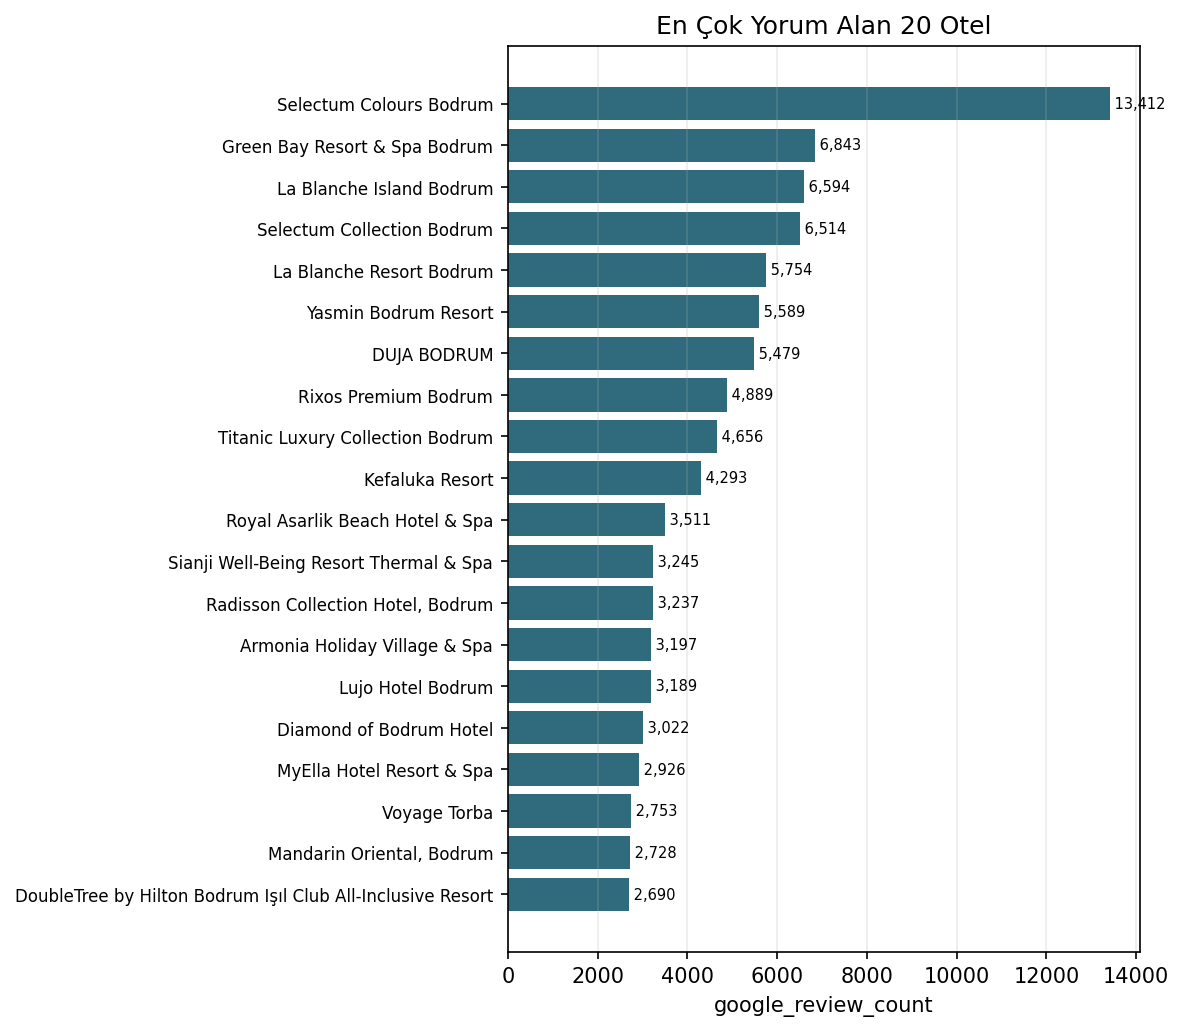

*Şekil 1 — Google yorum hacmine göre en görünür oteller (Notebook 05).*

### Grafik nasıl okunur?
Yatay eksen Google yorum sayısını; her çubuk bir oteli gösterir.

### Ne görüyoruz?
Dağılım birkaç çok yüksek görünürlüklü otelde yoğunlaşıyor; en yüksek gözlem 13.412 yorum.

### Neden önemli?
Yorum hacmi dijital görünürlük ve müşteri etkileşimi için yararlı bir pazar sinyalidir.

### Dikkat edilmesi gereken nokta
En çok yorum alan otel 'en iyi' değildir; yorum sayısı gerçek misafir veya rezervasyon sayısı değildir.

In [10]:
show_figure(
    "reports/figures/eda/hotels_by_review_count.png",
    "Şekil 1 — Google yorum hacmine göre en görünür oteller (Notebook 05).",
    "Yatay eksen Google yorum sayısını; her çubuk bir oteli gösterir.",
    "Dağılım birkaç çok yüksek görünürlüklü otelde yoğunlaşıyor; en yüksek gözlem " + format_number_tr(hotels["google_review_count"].max()) + " yorum.",
    "Yorum hacmi dijital görünürlük ve müşteri etkileşimi için yararlı bir pazar sinyalidir.",
    "En çok yorum alan otel 'en iyi' değildir; yorum sayısı gerçek misafir veya rezervasyon sayısı değildir."
)


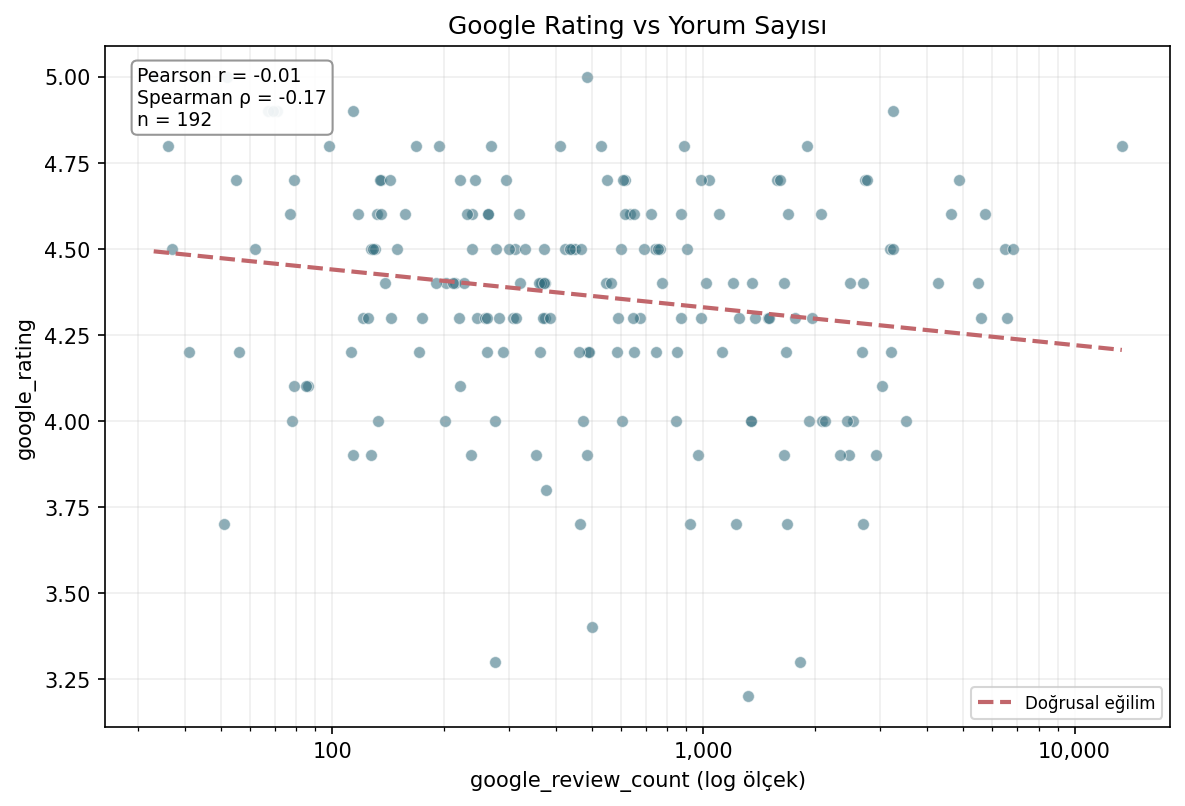

*Şekil 2 — Google puanı ile yorum hacmi ilişkisi (Notebook 05).*

### Grafik nasıl okunur?
Her nokta bir otel; yatay eksen yorum hacmi, dikey eksen müşteri puanıdır.

### Ne görüyoruz?
Yüksek görünürlük tek bir puan seviyesinde toplanmıyor; farklı quadrant ve outlier'lar var.

### Neden önemli?
Puan ile görünürlüğün farklı pazar boyutları olduğunu gösterir.

### Dikkat edilmesi gereken nokta
Kesitsel platform verisi nedensellik göstermez; rating ölçeği dar olduğu için küçük farklar abartılmamalıdır.

In [11]:
show_figure(
    "reports/figures/eda/rating_vs_review_count.png",
    "Şekil 2 — Google puanı ile yorum hacmi ilişkisi (Notebook 05).",
    "Her nokta bir otel; yatay eksen yorum hacmi, dikey eksen müşteri puanıdır.",
    "Yüksek görünürlük tek bir puan seviyesinde toplanmıyor; farklı quadrant ve outlier'lar var.",
    "Puan ile görünürlüğün farklı pazar boyutları olduğunu gösterir.",
    "Kesitsel platform verisi nedensellik göstermez; rating ölçeği dar olduğu için küçük farklar abartılmamalıdır."
)


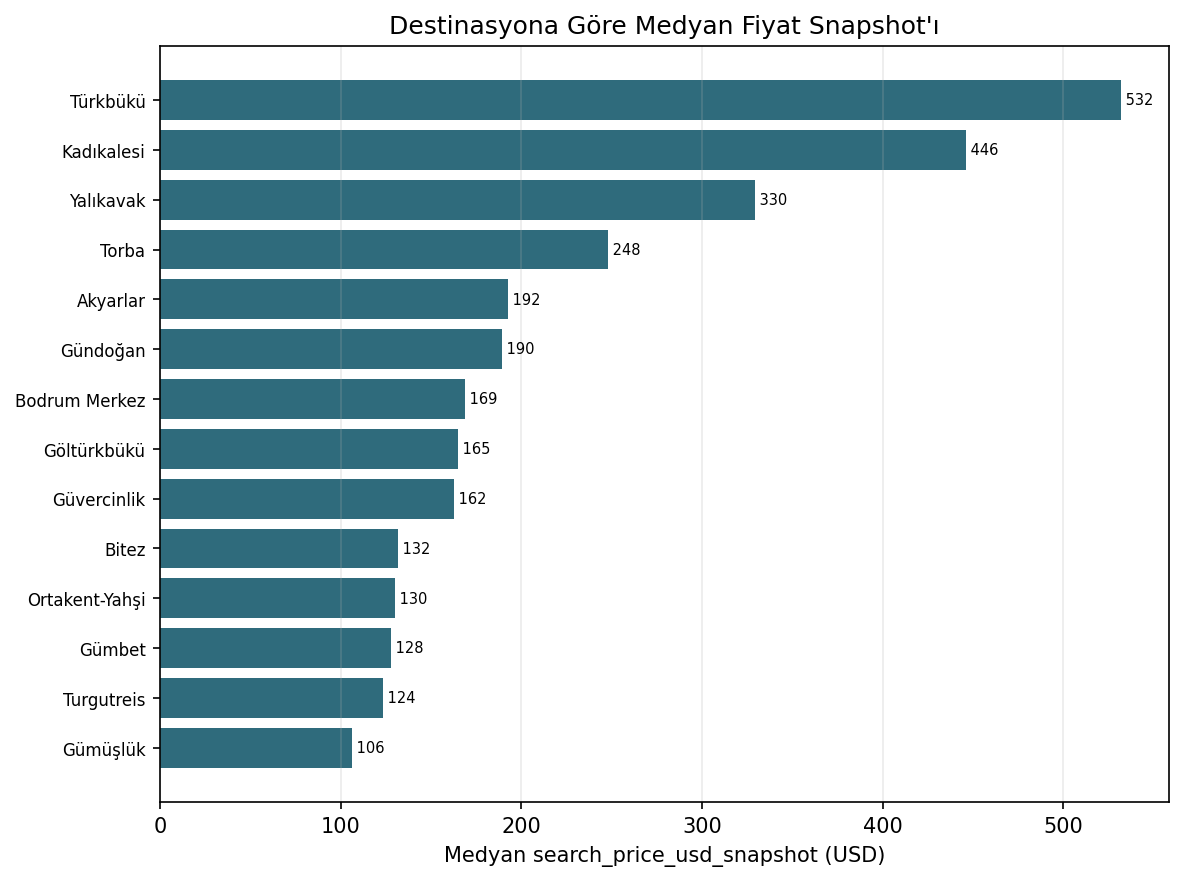

*Şekil 3 — Destinasyona göre medyan fiyat snapshot'ı (Notebook 05).*

### Grafik nasıl okunur?
Her çubuk alandaki dolu fiyat snapshot'larının medyanıdır; daha uzun çubuk daha yüksek göreli snapshot düzeyidir.

### Ne görüyoruz?
Türkbükü en yüksek fiyat indeksi sinyalini taşıyor (318,6; genel medyan=100).

### Neden önemli?
Destinasyonların aynı günkü göreli pazar konumlarının farklılaştığını gösterir.

### Dikkat edilmesi gereken nokta
Bu yıllık fiyat stratejisi değildir; oda, tarih, kişi ve rezervasyon koşulları bilinmeyen tek snapshot'tır.

In [12]:
show_figure(
    "reports/figures/eda/median_price_by_destination.png",
    "Şekil 3 — Destinasyona göre medyan fiyat snapshot'ı (Notebook 05).",
    "Her çubuk alandaki dolu fiyat snapshot'larının medyanıdır; daha uzun çubuk daha yüksek göreli snapshot düzeyidir.",
    f"{top_price_index['area']} en yüksek fiyat indeksi sinyalini taşıyor ({format_number_tr(top_price_index['price_index'], 1)}; genel medyan=100).",
    "Destinasyonların aynı günkü göreli pazar konumlarının farklılaştığını gösterir.",
    "Bu yıllık fiyat stratejisi değildir; oda, tarih, kişi ve rezervasyon koşulları bilinmeyen tek snapshot'tır."
)


### Bölüm Sonucu

Bodrum hotel snapshot'ı kalite, görünürlük ve fiyatın aynı kavram olmadığını gösteriyor. İşletmeci
için görünürlük ile puanı ayrı yönetmek; planlayıcı için destinasyon fiyat farklarını coverage ile
okumak; gezgin için tek bir fiyat veya puanı kesin kalite hükmüne çevirmemek gerekir.


## 08. Resmî Otel Özellikleri

In [13]:
display(Markdown(
    "#### Notebook 06 — Resmî match audit\n\n"
    f"- Project hotel: **{format_number_tr(match_map['total_project_hotels'])}**\n"
    f"- Official facility: **{format_number_tr(match_map['official_facilities_total'])}**\n"
    f"- High confidence: **{format_number_tr(match_map['high_confidence_matches'])}** — yalnız bu grupta resmî özellik kullanıldı.\n"
    f"- Review required: **{format_number_tr(match_map['review_required'])}** — otomatik enrichment dışında.\n"
    f"- Unmatched project hotel: **{format_number_tr(match_map['unmatched_project_hotels'])}** — resmî özellik atanmadı.\n"
    f"- Official conflicts: **{format_number_tr(match_map['official_conflicts'])}** — çelişki kaydı otomatik güven yaratmadı."
))


#### Notebook 06 — Resmî match audit

- Project hotel: **192**
- Official facility: **168**
- High confidence: **52** — yalnız bu grupta resmî özellik kullanıldı.
- Review required: **48** — otomatik enrichment dışında.
- Unmatched project hotel: **92** — resmî özellik atanmadı.
- Official conflicts: **8** — çelişki kaydı otomatik güven yaratmadı.

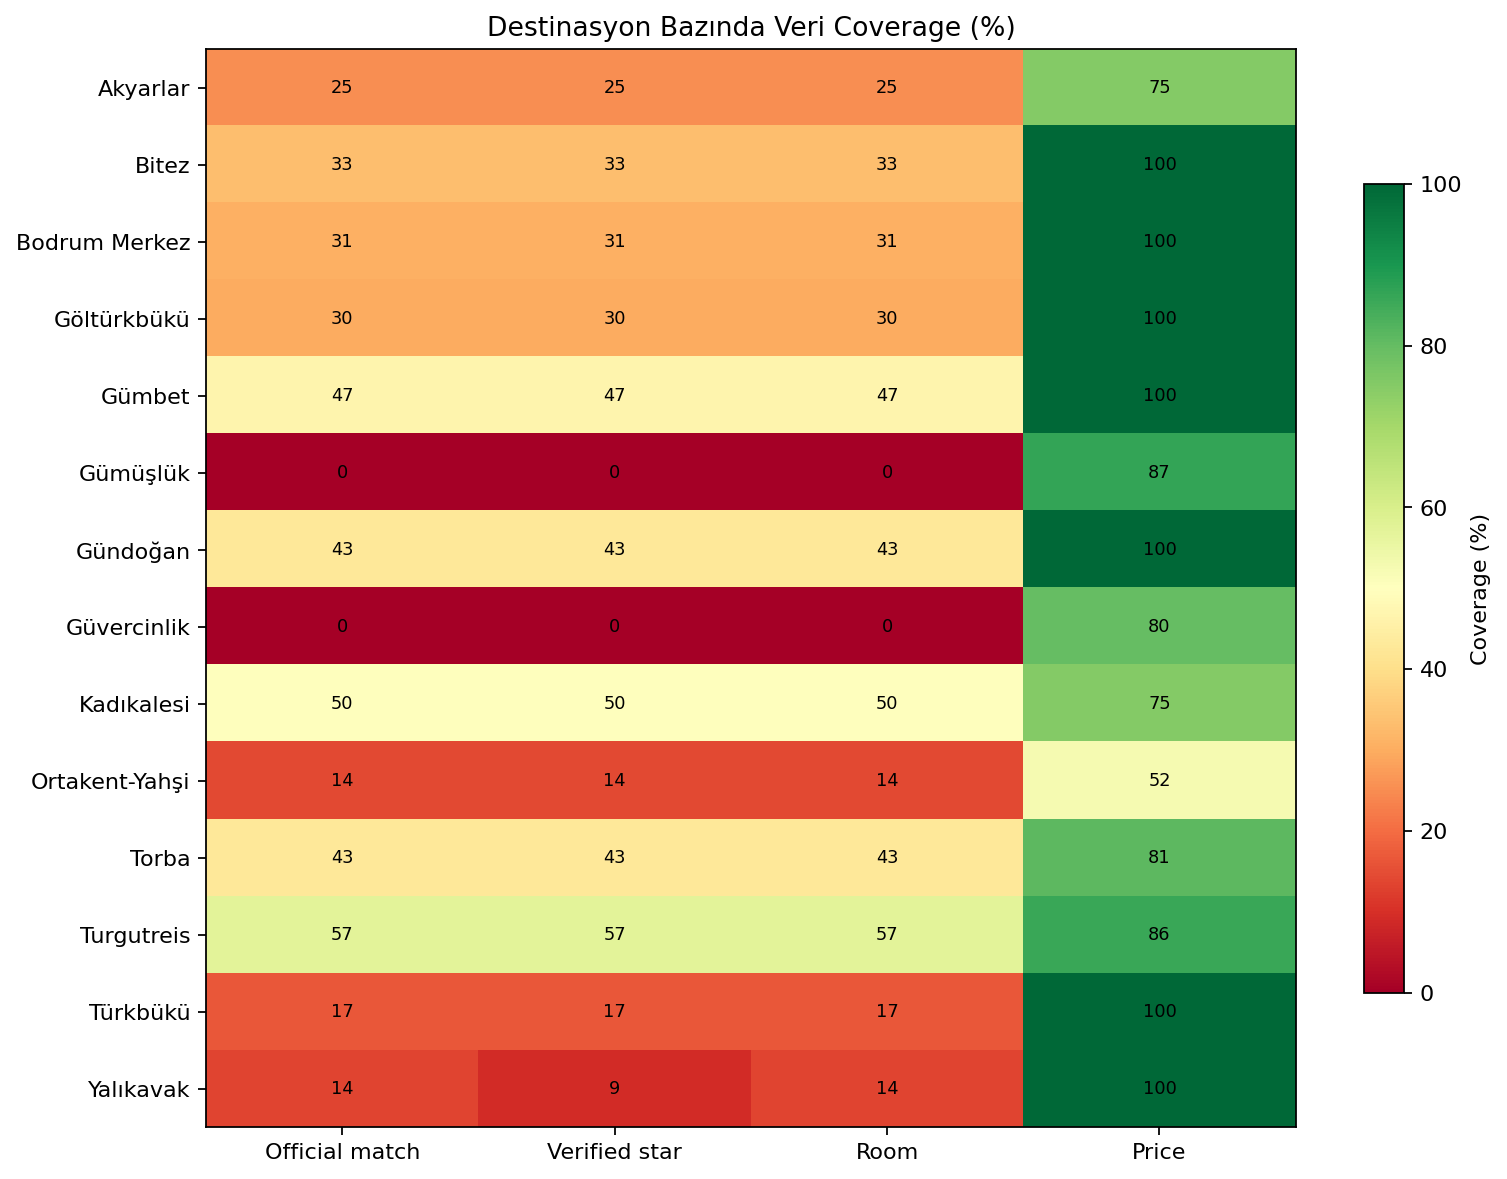

*Şekil 4 — Destinasyon bazında resmî eşleşme coverage'ı (Notebook 06/08).*

### Grafik nasıl okunur?
Çubuklar, her alandaki örneklem otellerinin kaçında yüksek güvenli resmî eşleşme bulunduğunu gösterir.

### Ne görüyoruz?
Toplam coverage 52/192 (%27,1); 14 alanın 10'u düşük coverage işareti taşıyor.

### Neden önemli?
Yıldız, oda, yatak ve luxury sonuçlarının hangi alanlarda daha güvenilir olduğunu belirler.

### Dikkat edilmesi gereken nokta
Coverage düşüklüğü kapasitenin gerçekten düşük olduğunu göstermez; yalnız gözlenebilir resmî eşleşmenin sınırlı olduğunu gösterir.

In [14]:
show_figure(
    "reports/figures/destination_intelligence/coverage_by_area.png",
    "Şekil 4 — Destinasyon bazında resmî eşleşme coverage'ı (Notebook 06/08).",
    "Çubuklar, her alandaki örneklem otellerinin kaçında yüksek güvenli resmî eşleşme bulunduğunu gösterir.",
    f"Toplam coverage {format_number_tr(high_confidence_n)}/{format_number_tr(hotel_count)} ({format_pct_tr(official_coverage_pct)}); 14 alanın 10'u düşük coverage işareti taşıyor.",
    "Yıldız, oda, yatak ve luxury sonuçlarının hangi alanlarda daha güvenilir olduğunu belirler.",
    "Coverage düşüklüğü kapasitenin gerçekten düşük olduğunu göstermez; yalnız gözlenebilir resmî eşleşmenin sınırlı olduğunu gösterir."
)


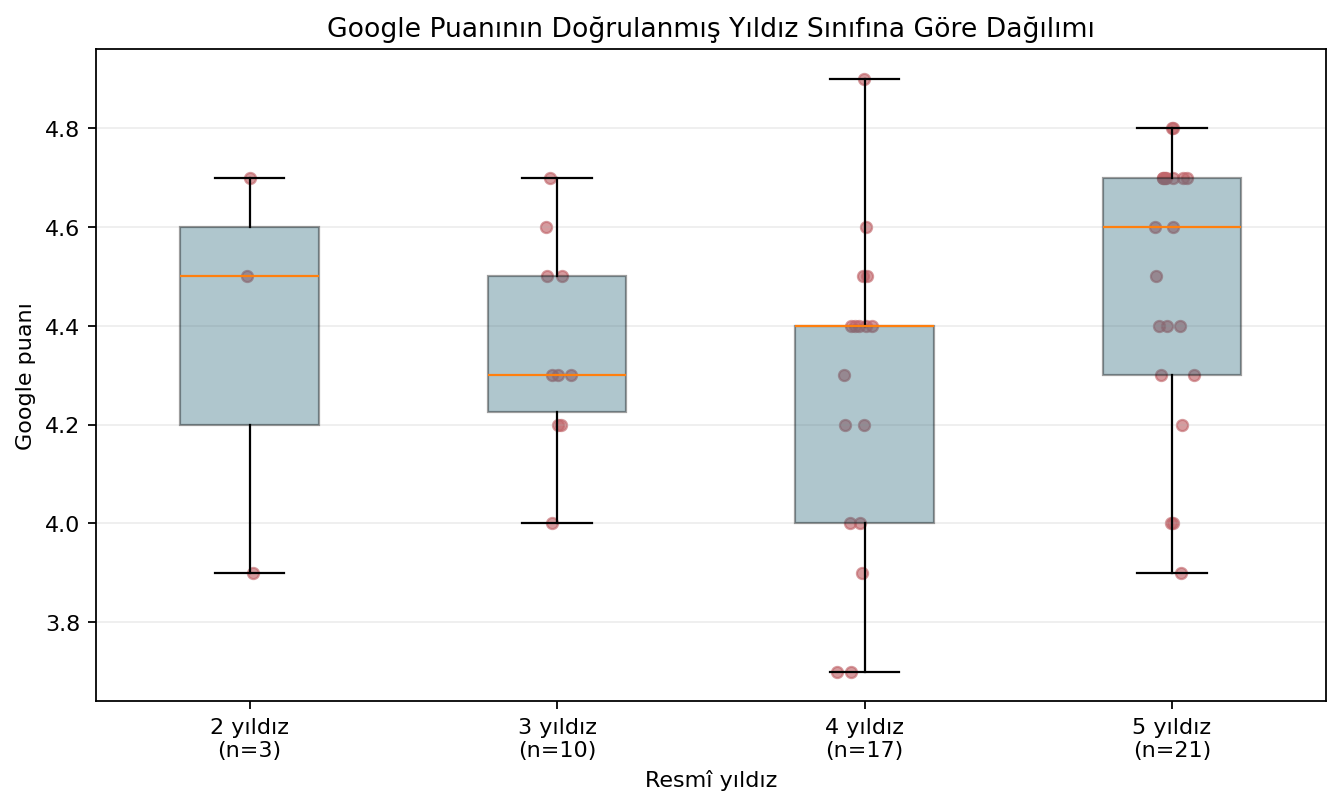

*Şekil 5 — Doğrulanmış yıldız sınıfına göre Google puanı (Notebook 07).*

### Grafik nasıl okunur?
Kutular yıldız gruplarındaki rating dağılımını; noktalar otelleri gösterir.

### Ne görüyoruz?
Yıldız ile rating ilişkisi zayıf ve istatistiksel olarak net değil: ρ=0,24, p=0,092, n=51.

### Neden önemli?
Resmî sınıf ile müşteri algısının birbirini tamamlayan ama aynı olmayan boyutlar olduğunu gösterir.

### Dikkat edilmesi gereken nokta
Küçük yıldız grupları ve yalnız yüksek güvenli eşleşmeler vardır; nedensellik kurulamaz.

In [15]:
show_figure(
    "reports/figures/hotel_attributes/rating_by_star.png",
    "Şekil 5 — Doğrulanmış yıldız sınıfına göre Google puanı (Notebook 07).",
    "Kutular yıldız gruplarındaki rating dağılımını; noktalar otelleri gösterir.",
    f"Yıldız ile rating ilişkisi zayıf ve istatistiksel olarak net değil: ρ={format_number_tr(star_rating_row['statistic'], 2)}, p={format_number_tr(star_rating_row['p_value'], 3)}, n={int(star_rating_row['n'])}.",
    "Resmî sınıf ile müşteri algısının birbirini tamamlayan ama aynı olmayan boyutlar olduğunu gösterir.",
    "Küçük yıldız grupları ve yalnız yüksek güvenli eşleşmeler vardır; nedensellik kurulamaz."
)


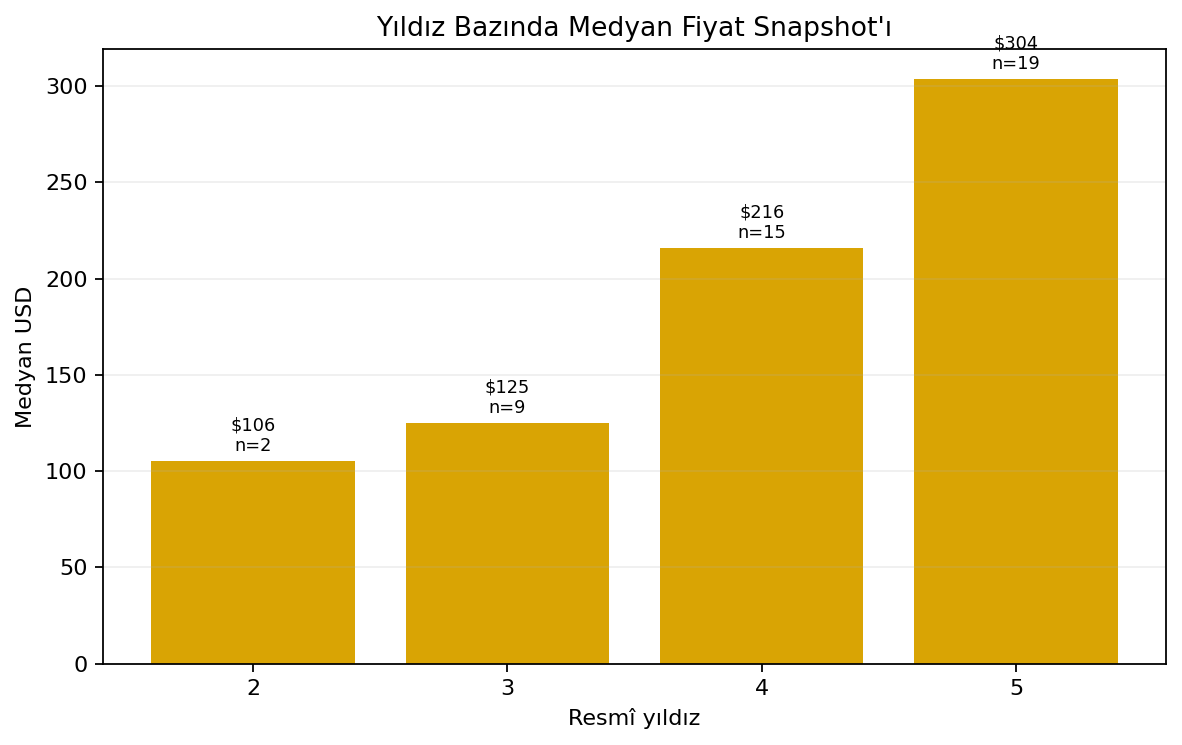

*Şekil 6 — Doğrulanmış yıldız sınıfına göre medyan fiyat snapshot'ı (Notebook 07).*

### Grafik nasıl okunur?
Çubuk yüksekliği yıldız grubunun medyan fiyat snapshot'ını, etiketler fiyat gözlem sayısını gösterir.

### Ne görüyoruz?
5 yıldız medyanı $304 (n=19); 4 yıldız medyanı $216 (n=15); fark %40,7.

### Neden önemli?
Resmî sınıfın snapshot fiyat konumuyla birlikte değişebildiğini gösterir.

### Dikkat edilmesi gereken nokta
Fiyat tek tarihlidir; grup büyüklükleri sınırlıdır ve sonuç kalıcı fiyatlama stratejisi değildir.

In [16]:
star4 = star_summary.loc[star_summary["star"].eq(4)].iloc[0]
star5 = star_summary.loc[star_summary["star"].eq(5)].iloc[0]
star_price_diff_pct = (star5["median_price_snapshot"] / star4["median_price_snapshot"] - 1) * 100
show_figure(
    "reports/figures/hotel_attributes/median_price_by_star.png",
    "Şekil 6 — Doğrulanmış yıldız sınıfına göre medyan fiyat snapshot'ı (Notebook 07).",
    "Çubuk yüksekliği yıldız grubunun medyan fiyat snapshot'ını, etiketler fiyat gözlem sayısını gösterir.",
    f"5 yıldız medyanı ${format_number_tr(star5['median_price_snapshot'])} (n={int(star5['price_n'])}); 4 yıldız medyanı ${format_number_tr(star4['median_price_snapshot'])} (n={int(star4['price_n'])}); fark {format_pct_tr(star_price_diff_pct)}.",
    "Resmî sınıfın snapshot fiyat konumuyla birlikte değişebildiğini gösterir.",
    "Fiyat tek tarihlidir; grup büyüklükleri sınırlıdır ve sonuç kalıcı fiyatlama stratejisi değildir."
)


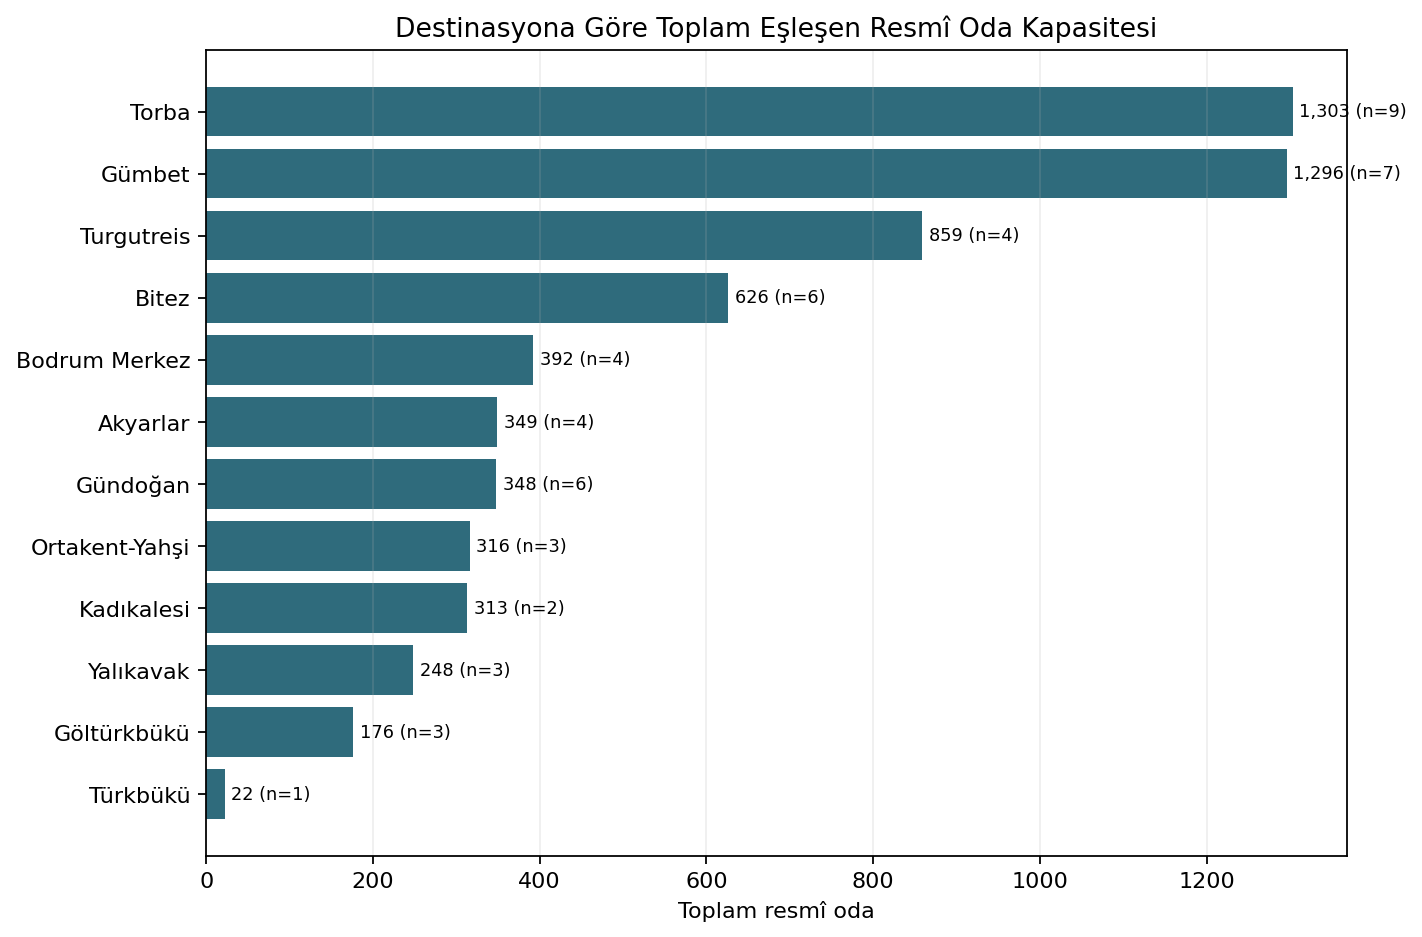

*Şekil 7 — Yüksek güvenli eşleşmelerde destinasyon resmî oda kapasitesi (Notebook 07).*

### Grafik nasıl okunur?
Çubuklar eşleşen tesislerin oda toplamını; etiketler kapsanan otel sayısını gösterir.

### Ne görüyoruz?
İlk üç alan: Torba 1.303, Gümbet 1.296, Turgutreis 859 oda.

### Neden önemli?
Otel adedi ile konaklama kapasitesinin aynı olmadığını gösterir.

### Dikkat edilmesi gereken nokta
Yalnız eşleşen tesislerin kapasitesidir; düşük coverage alanlarında gerçek toplamı eksik gösterebilir.

In [17]:
top_capacity = capacity.nlargest(3, "total_official_rooms")
show_figure(
    "reports/figures/hotel_attributes/destination_room_capacity.png",
    "Şekil 7 — Yüksek güvenli eşleşmelerde destinasyon resmî oda kapasitesi (Notebook 07).",
    "Çubuklar eşleşen tesislerin oda toplamını; etiketler kapsanan otel sayısını gösterir.",
    "İlk üç alan: " + ", ".join(f"{r.area} {format_number_tr(r.total_official_rooms)}" for r in top_capacity.itertuples()) + " oda.",
    "Otel adedi ile konaklama kapasitesinin aynı olmadığını gösterir.",
    "Yalnız eşleşen tesislerin kapasitesidir; düşük coverage alanlarında gerçek toplamı eksik gösterebilir."
)


### Bölüm Sonucu

Resmî yıldız ve kapasite, müşteri algısına ek bir yapı katmanı sağlıyor; rating'in yerine geçmiyor.
İşletmeci ve planlayıcı için kapasite toplamları yararlı, fakat yalnız yüksek güvenli eşleşme evreninde
geçerli. Gezgin açısından yıldız ve Google puanı farklı beklenti türlerini temsil ediyor.


## 09. Destination Intelligence

In [18]:
destination_overview = destination[[
    "area", "sample_hotel_count", "avg_weighted_google_rating", "reviews_per_sample_hotel",
    "price_index", "total_official_rooms", "verified_five_star_share", "score_confidence",
]].copy()
destination_overview.columns = [
    "Area", "Hotel n", "Weighted rating", "Review intensity", "Price index",
    "Official rooms", "Verified 5★ share", "Score confidence",
]
destination_overview = destination_overview.sort_values("Weighted rating", ascending=False)
destination_overview["Weighted rating"] = destination_overview["Weighted rating"].round(3)
destination_overview["Review intensity"] = destination_overview["Review intensity"].round(0)
destination_overview["Price index"] = destination_overview["Price index"].round(1)
destination_overview["Verified 5★ share"] = (destination_overview["Verified 5★ share"] * 100).round(1)
table_title("14 destinasyonun kısa profili", "Boş resmî kapasite sıfır değildir; yüksek güvenli match gözlemi yoktur. Price index'te Bodrum medyanı=100.")
display(destination_overview)


#### 14 destinasyonun kısa profili

Boş resmî kapasite sıfır değildir; yüksek güvenli match gözlemi yoktur. Price index'te Bodrum medyanı=100.

,Area,Hotel n,Weighted rating,Review intensity,Price index,Official rooms,Verified 5★ share,Score confidence
6,Gündoğan,14,4.417,466.0,113.5,348.0,16.7,high
3,Göltürkbükü,10,4.416,601.0,98.8,176.0,33.3,medium
10,Torba,21,4.400,1129.0,148.5,1303.0,55.6,high
0,Akyarlar,16,4.395,1714.0,115.3,349.0,0.0,medium
5,Gümüşlük,15,4.392,278.0,63.5,NaN,NaN,low
13,Yalıkavak,22,4.391,435.0,197.3,248.0,100.0,medium
11,Turgutreis,7,4.391,2014.0,74.0,859.0,100.0,medium
12,Türkbükü,6,4.387,612.0,318.6,22.0,0.0,low
9,Ortakent-Yahşi,21,4.334,470.0,77.8,316.0,0.0,low
8,Kadıkalesi,4,4.309,2880.0,267.1,313.0,50.0,low


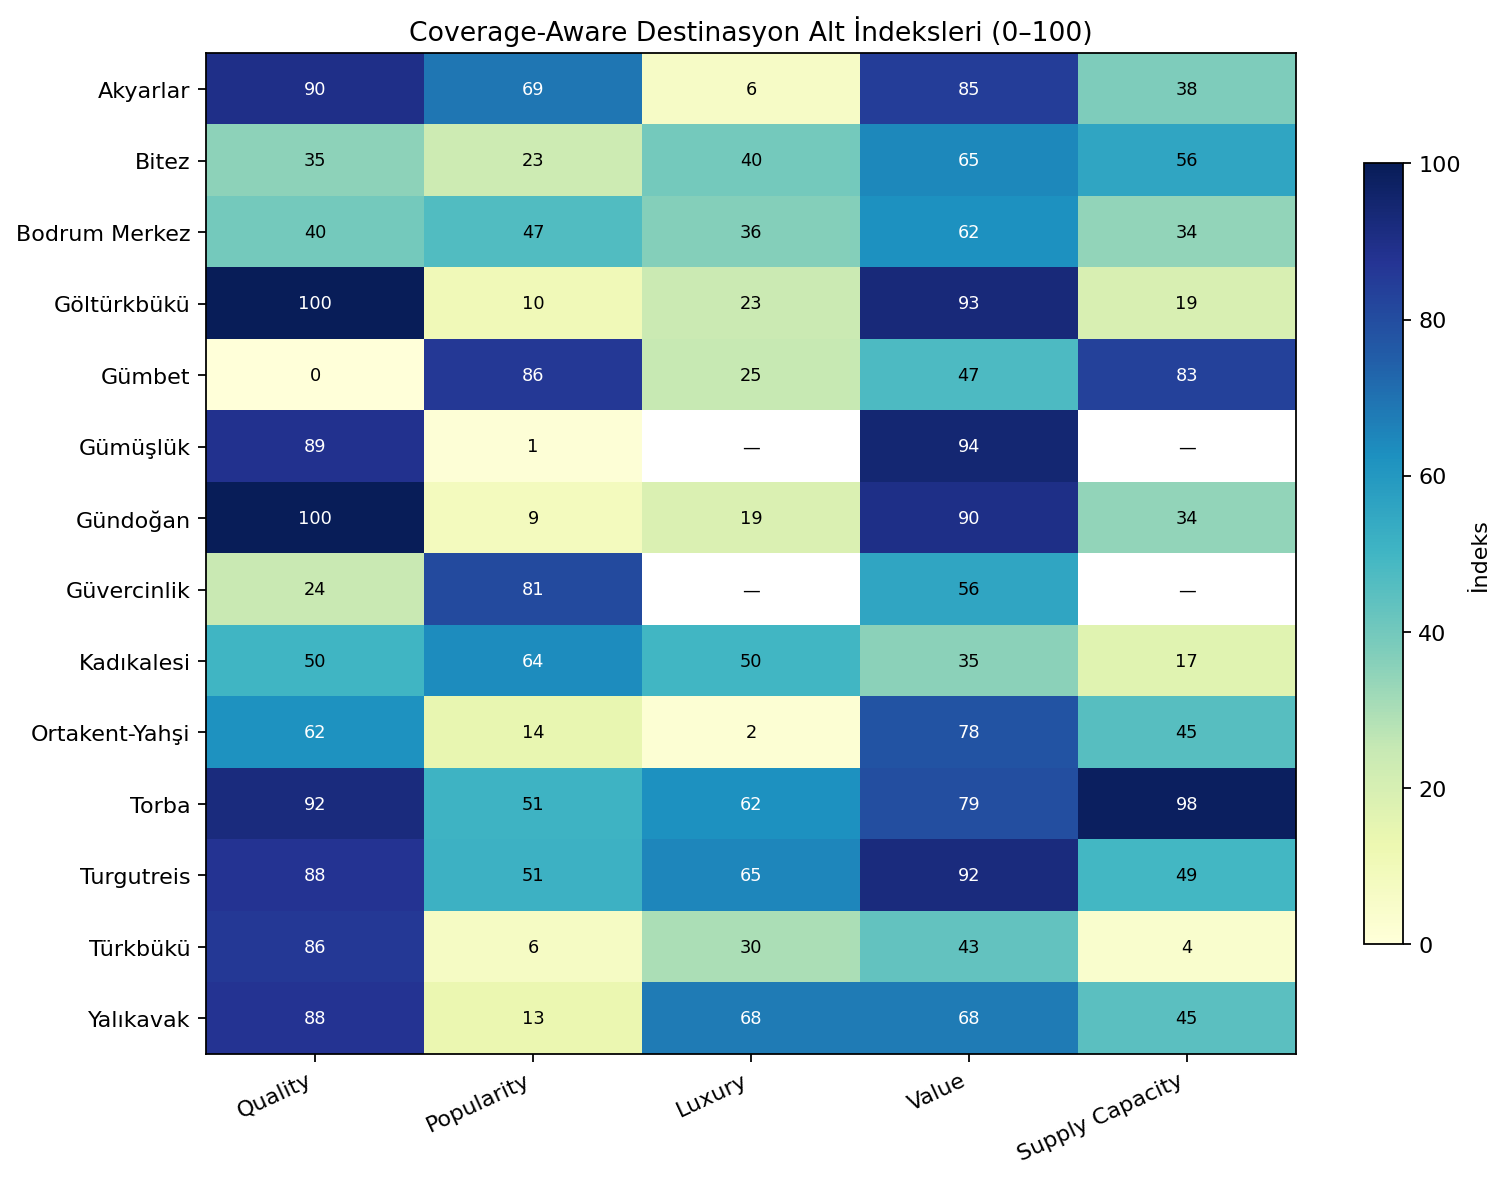

*Şekil 8 — Destinasyon alt indeksleri heatmap'i (Notebook 08).*

### Grafik nasıl okunur?
Her satır bir destinasyon; sütunlar quality, popularity, luxury, value ve supply/capacity boyutlarının 0–100 göreli indeksidir.

### Ne görüyoruz?
Alanlar aynı sütunlarda farklı profiller veriyor; tek bir alan bütün boyutlarda baskın değil.

### Neden önemli?
Farklı turist ve planlama ihtiyaçlarının farklı boyutlara ağırlık vereceğini görünür kılar.

### Dikkat edilmesi gereken nokta
İndeksler örneklem içi göreli ölçüdür; luxury/capacity özellikle düşük coverage alanlarında kesin rank değildir.

In [19]:
show_figure(
    "reports/figures/destination_intelligence/destination_subindices_heatmap.png",
    "Şekil 8 — Destinasyon alt indeksleri heatmap'i (Notebook 08).",
    "Her satır bir destinasyon; sütunlar quality, popularity, luxury, value ve supply/capacity boyutlarının 0–100 göreli indeksidir.",
    "Alanlar aynı sütunlarda farklı profiller veriyor; tek bir alan bütün boyutlarda baskın değil.",
    "Farklı turist ve planlama ihtiyaçlarının farklı boyutlara ağırlık vereceğini görünür kılar.",
    "İndeksler örneklem içi göreli ölçüdür; luxury/capacity özellikle düşük coverage alanlarında kesin rank değildir."
)


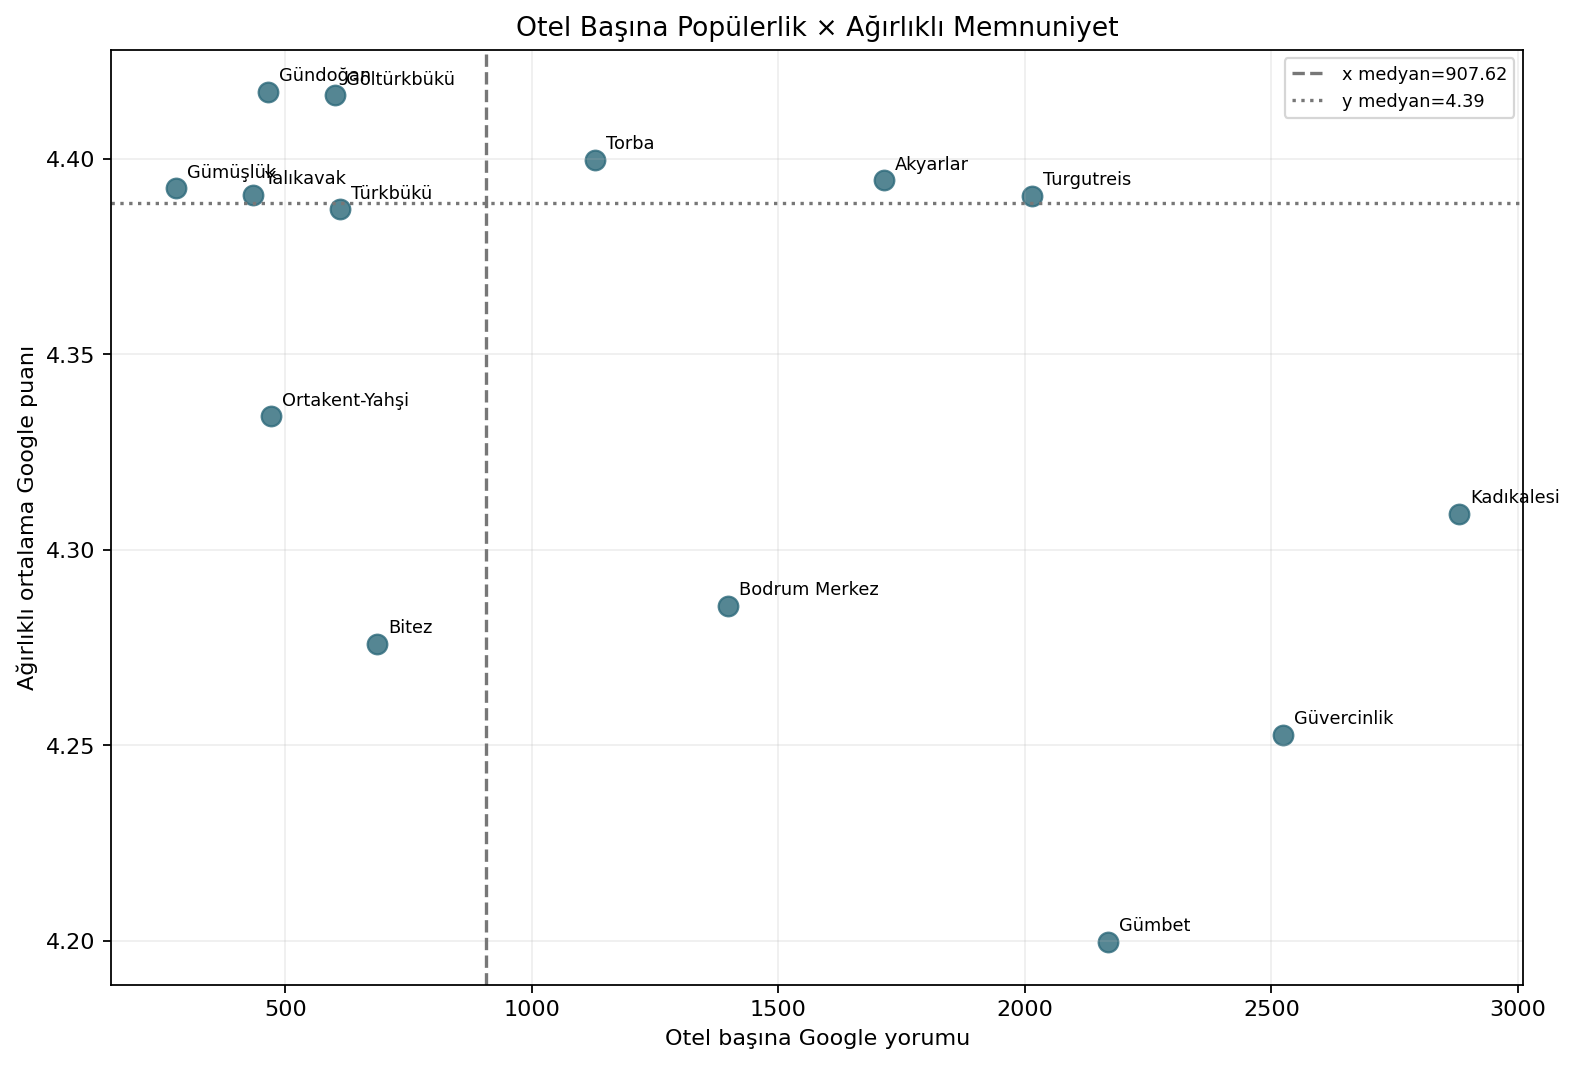

*Şekil 9 — Popularity × satisfaction quadrant (Notebook 08).*

### Grafik nasıl okunur?
Sağ taraf daha yüksek yorum yoğunluğu, üst taraf daha yüksek ağırlıklı memnuniyet sinyalidir; çizgiler örneklem medyanlarını ayırır.

### Ne görüyoruz?
Gümbet görünürlük hacminde; Gündoğan ağırlıklı memnuniyette öne çıkıyor, fakat aynı boyutu temsil etmiyorlar.

### Neden önemli?
Destinasyonların yüksek görünürlük ve yüksek memnuniyet kombinasyonlarını ayrı okumayı sağlar.

### Dikkat edilmesi gereken nokta
Quadrant sınırları örneklem medyanıdır; küçük konum farkları kesin kategori farkı değildir.

In [20]:
show_figure(
    "reports/figures/destination_intelligence/popularity_satisfaction_quadrant.png",
    "Şekil 9 — Popularity × satisfaction quadrant (Notebook 08).",
    "Sağ taraf daha yüksek yorum yoğunluğu, üst taraf daha yüksek ağırlıklı memnuniyet sinyalidir; çizgiler örneklem medyanlarını ayırır.",
    f"{top_reviews['area']} görünürlük hacminde; {top_weighted['area']} ağırlıklı memnuniyette öne çıkıyor, fakat aynı boyutu temsil etmiyorlar.",
    "Destinasyonların yüksek görünürlük ve yüksek memnuniyet kombinasyonlarını ayrı okumayı sağlar.",
    "Quadrant sınırları örneklem medyanıdır; küçük konum farkları kesin kategori farkı değildir."
)


### Tek bir “destination score” neden yok?

Tek bir en iyi destinasyon yoktur; farklı turist profilleri quality, popularity, price, luxury,
value veya capacity boyutlarına farklı önem verir. Notebook 08 bu nedenle ayrı alt indeksleri ve
açıklanabilir archetype'ları korur. “Value-Oriented” veya “Capacity-Heavy Resort Area” gibi etiketler
ML cluster değil, gözlenebilir kurallara dayalı kısa profil adlarıdır.

### Bölüm Sonucu

Destinasyonlar tek eksende sıralanmak yerine çok boyutlu profillerle ayrışıyor. Planlayıcı coverage'ı
rank'in parçası olarak görmeli; işletmeci kendi rekabet bağlamını seçmeli; gezgin önceliğine uyan
boyutu değerlendirmeli.


## 10. Tourism Demand 2009–2025

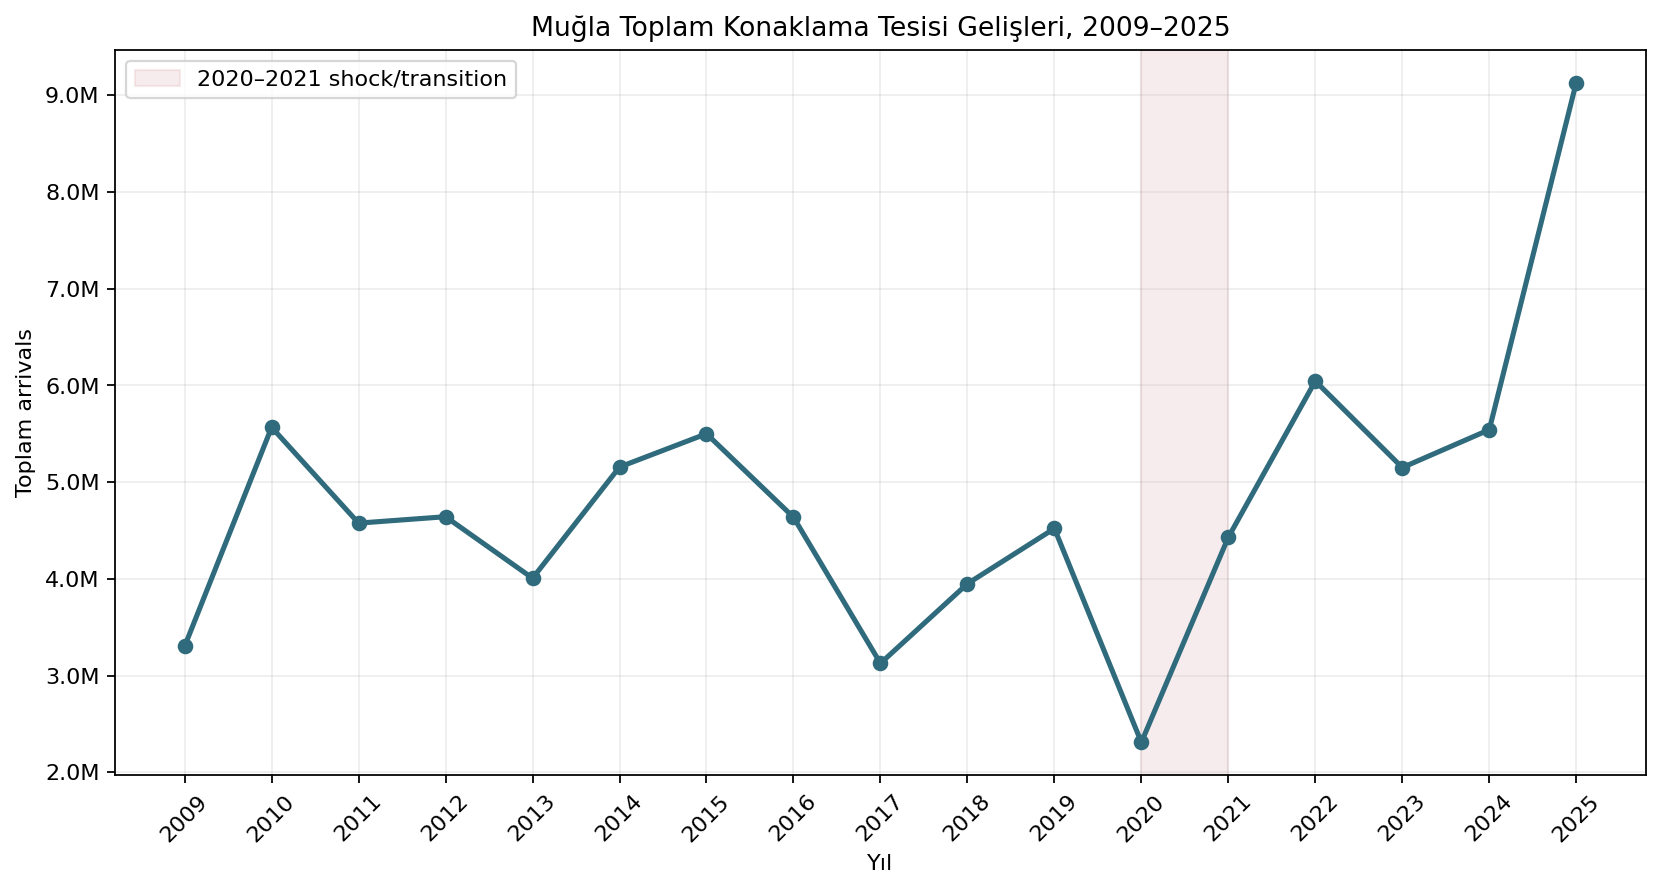

*Şekil 10 — Muğla toplam konaklama tesisi gelişleri, 2009–2025 (Notebook 09).*

### Grafik nasıl okunur?
Çizgi yıllık toplam gelişleri gösterir; işaretli yıllar 2019 benchmark, 2020 kırılması ve sonraki toparlanmadır.

### Ne görüyoruz?
2009'da 3.302.223 olan geliş 2025'te 9.129.867; 2020'de 2019'a göre %-48,9 değişim var.

### Neden önemli?
Pazarın uzun dönem ölçeğini ve pandemi kırılmasını aynı bağlamda gösterir.

### Dikkat edilmesi gereken nokta
Seri Muğla ili konaklama istatistiğidir; Bodrum otel snapshot'ıyla satır bazında birleşmez.

In [21]:
show_figure(
    "reports/figures/tourism_demand/01_total_arrivals_2009_2025.png",
    "Şekil 10 — Muğla toplam konaklama tesisi gelişleri, 2009–2025 (Notebook 09).",
    "Çizgi yıllık toplam gelişleri gösterir; işaretli yıllar 2019 benchmark, 2020 kırılması ve sonraki toparlanmadır.",
    f"2009'da {format_number_tr(tourism_annual.iloc[0]['total_arrivals'])} olan geliş 2025'te {format_number_tr(annual_2025['total_arrivals'])}; 2020'de 2019'a göre {format_pct_tr(annual_2020['total_arrivals_yoy_pct'])} değişim var.",
    "Pazarın uzun dönem ölçeğini ve pandemi kırılmasını aynı bağlamda gösterir.",
    "Seri Muğla ili konaklama istatistiğidir; Bodrum otel snapshot'ıyla satır bazında birleşmez."
)


### Bölüm Sonucu

Muğla talebi uzun dönemde belirgin büyüdü; 2020 keskin bir kırılma, 2022 sonrası dönem ise daha yüksek
ölçekli bir toparlanma gösterdi. 2025 toplam geliş, yabancı geliş ve gecelemelerde serinin en yüksek yılıdır;
ancak ortalama kalış 2019'dan daha kısadır.


## 11. 2025 Seasonality

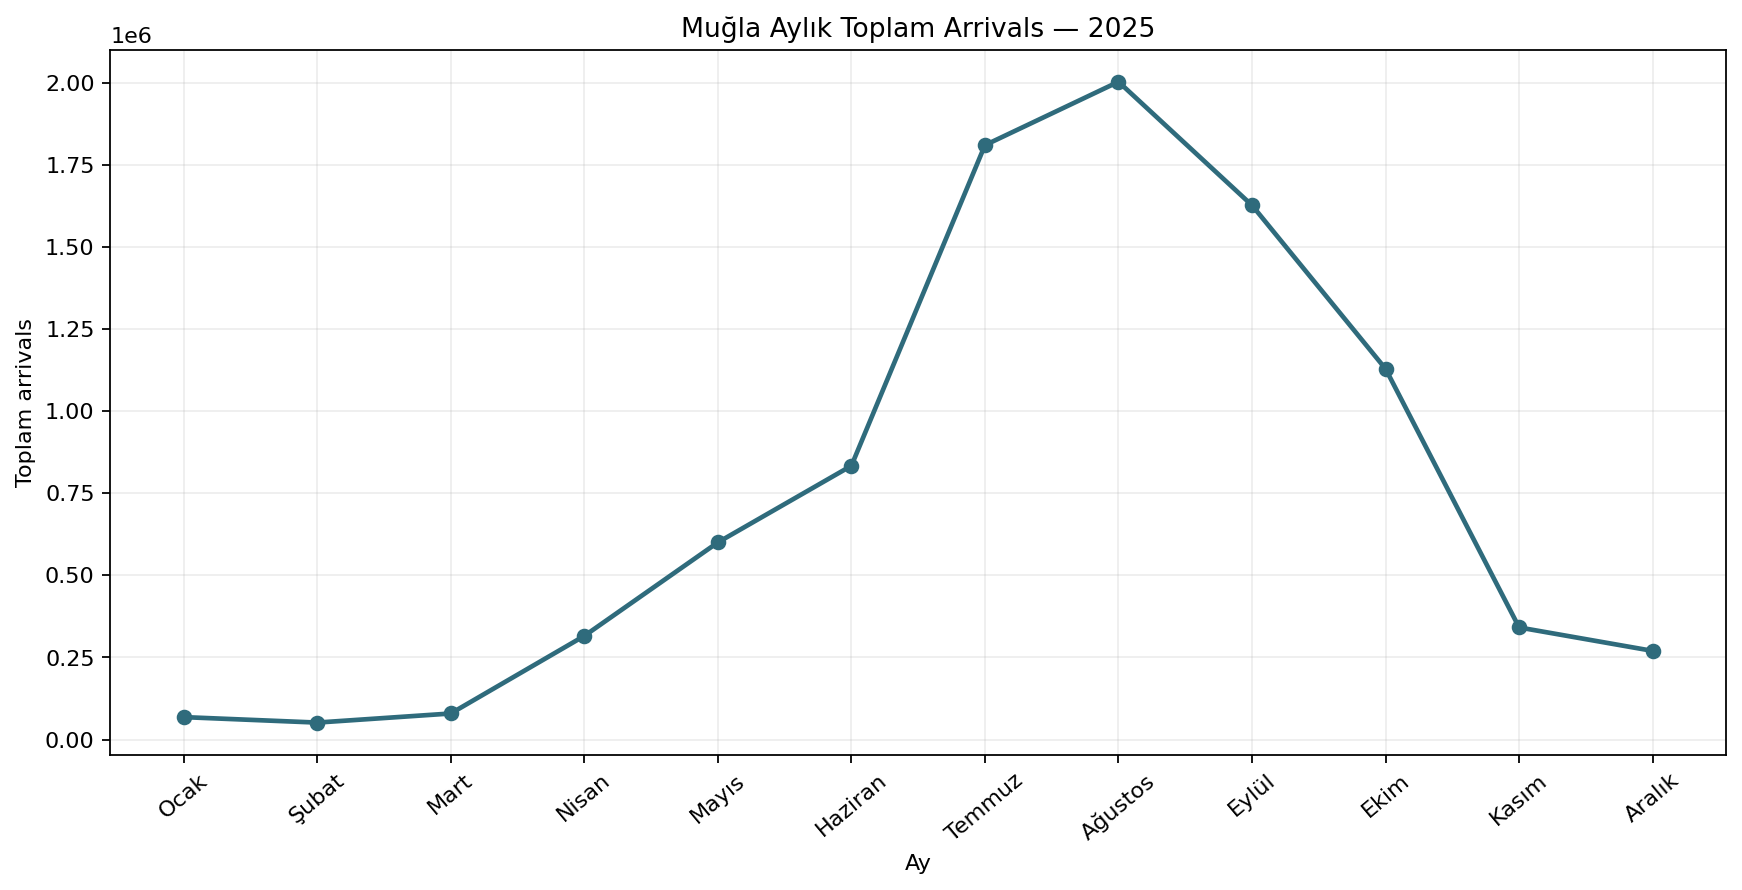

*Şekil 11 — Muğla 2025 aylık toplam geliş sezonluğu (Notebook 09).*

### Grafik nasıl okunur?
Çubuk/çizgi her ayın il düzeyi konaklama tesisi gelişini gösterir.

### Ne görüyoruz?
Peak Ağustos ayında 2.003.174; ilk üç ay payı %59,6, peak/low oranı 38,7.

### Neden önemli?
Kapasite, operasyon ve ulaşım planlamasında sezon yoğunlaşmasının ölçeğini gösterir.

### Dikkat edilmesi gereken nokta
Aylık seri Muğla il düzeyidir; Bodrum aylık talebi olarak etiketlenemez.

In [22]:
show_figure(
    "reports/figures/tourism_demand/06_monthly_total_arrivals_2025.png",
    "Şekil 11 — Muğla 2025 aylık toplam geliş sezonluğu (Notebook 09).",
    "Çubuk/çizgi her ayın il düzeyi konaklama tesisi gelişini gösterir.",
    f"Peak {peak_tourism['month_name_tr']} ayında {format_number_tr(peak_tourism['total_arrivals'])}; ilk üç ay payı {format_pct_tr(seasonality['top3_month_arrival_share_pct'])}, peak/low oranı {format_number_tr(seasonality['peak_to_low_arrival_ratio'], 1)}.",
    "Kapasite, operasyon ve ulaşım planlamasında sezon yoğunlaşmasının ölçeğini gösterir.",
    "Aylık seri Muğla il düzeyidir; Bodrum aylık talebi olarak etiketlenemez."
)


In [23]:
season_table = pd.DataFrame([
    ("Peak ay", peak_tourism["month_name_tr"], format_number_tr(peak_tourism["total_arrivals"])),
    ("İlk 3 ay payı", "Ağustos–Temmuz–Eylül", format_pct_tr(seasonality["top3_month_arrival_share_pct"])),
    ("Peak / low oranı", "Toplam geliş", format_number_tr(seasonality["peak_to_low_arrival_ratio"], 1)),
    ("HHI", "Aylık geliş yoğunlaşması", format_number_tr(seasonality["hhi_monthly_arrival_concentration"], 3)),
    ("En yüksek doluluk", tourism_monthly.loc[tourism_monthly["occupancy_rate_pct"].idxmax(), "month_name_tr"], format_pct_tr(tourism_monthly["occupancy_rate_pct"].max())),
    ("En uzun ortalama kalış", tourism_monthly.loc[tourism_monthly["derived_avg_stay_nights_recalculated"].idxmax(), "month_name_tr"], format_number_tr(tourism_monthly["derived_avg_stay_nights_recalculated"].max(), 2) + " gece"),
], columns=["Metrik", "Dönem", "Değer"])
table_title("Muğla 2025 sezon yoğunlaşması", "HHI, aylık payların kareleri toplamıdır; 1'e yaklaştıkça yoğunlaşma artar.")
display(season_table)


#### Muğla 2025 sezon yoğunlaşması

HHI, aylık payların kareleri toplamıdır; 1'e yaklaştıkça yoğunlaşma artar.

,Metrik,Dönem,Değer
0,Peak ay,Ağustos,2.003.174
1,İlk 3 ay payı,Ağustos–Temmuz–Eylül,"%59,6"
2,Peak / low oranı,Toplam geliş,"38,7"
3,HHI,Aylık geliş yoğunlaşması,"0,151"
4,En yüksek doluluk,Ağustos,"%75,8"
5,En uzun ortalama kalış,Haziran,"3,14 gece"


> **Coğrafya uyarısı:** Muğla aylık turizm serisi Bodrum aylık turizm serisi değildir.

### Bölüm Sonucu

2025 talebi yaz aylarında keskin biçimde yoğunlaştı. Planlamada peak ölçeği kadar shoulder/low sezon
farkı da önemlidir; bu sonuç Bodrum'a aylık sayı atamaz, yalnız Muğla il bağlamını verir.


## 12. Bodrum 2025 Annual Profile

In [24]:
bodrum_kpis = pd.DataFrame([
    ("Domestic arrivals", format_number_tr(bodrum_2025["domestic_arrivals"])),
    ("Foreign arrivals", format_number_tr(bodrum_2025["foreign_arrivals"])),
    ("Total arrivals", format_number_tr(bodrum_2025["total_arrivals"])),
    ("Total overnights", format_number_tr(bodrum_2025["total_overnights"])),
    ("Average stay", format_number_tr(bodrum_2025["avg_stay_nights_recalculated"], 2) + " gece"),
    ("Foreign share", format_pct_tr(bodrum_2025["foreign_share_pct"])),
    ("Muğla arrivals içindeki pay", format_pct_tr(bodrum_vs_mugla["bodrum_share_of_mugla_total_arrivals_pct"])),
    ("Muğla overnights içindeki pay", format_pct_tr(bodrum_vs_mugla["bodrum_share_of_mugla_total_overnights_pct"])),
], columns=["KPI", "Bodrum 2025"])
table_title("Bodrum 2025 yıllık profil", "Bodrum için aylık değil, yıllık ilçe kırılımı mevcuttur.")
display(bodrum_kpis)


#### Bodrum 2025 yıllık profil

Bodrum için aylık değil, yıllık ilçe kırılımı mevcuttur.

,KPI,Bodrum 2025
0,Domestic arrivals,1.624.032
1,Foreign arrivals,1.199.393
2,Total arrivals,2.823.425
3,Total overnights,7.579.360
4,Average stay,"2,68 gece"
5,Foreign share,"%42,5"
6,Muğla arrivals içindeki pay,"%30,9"
7,Muğla overnights içindeki pay,"%30,7"


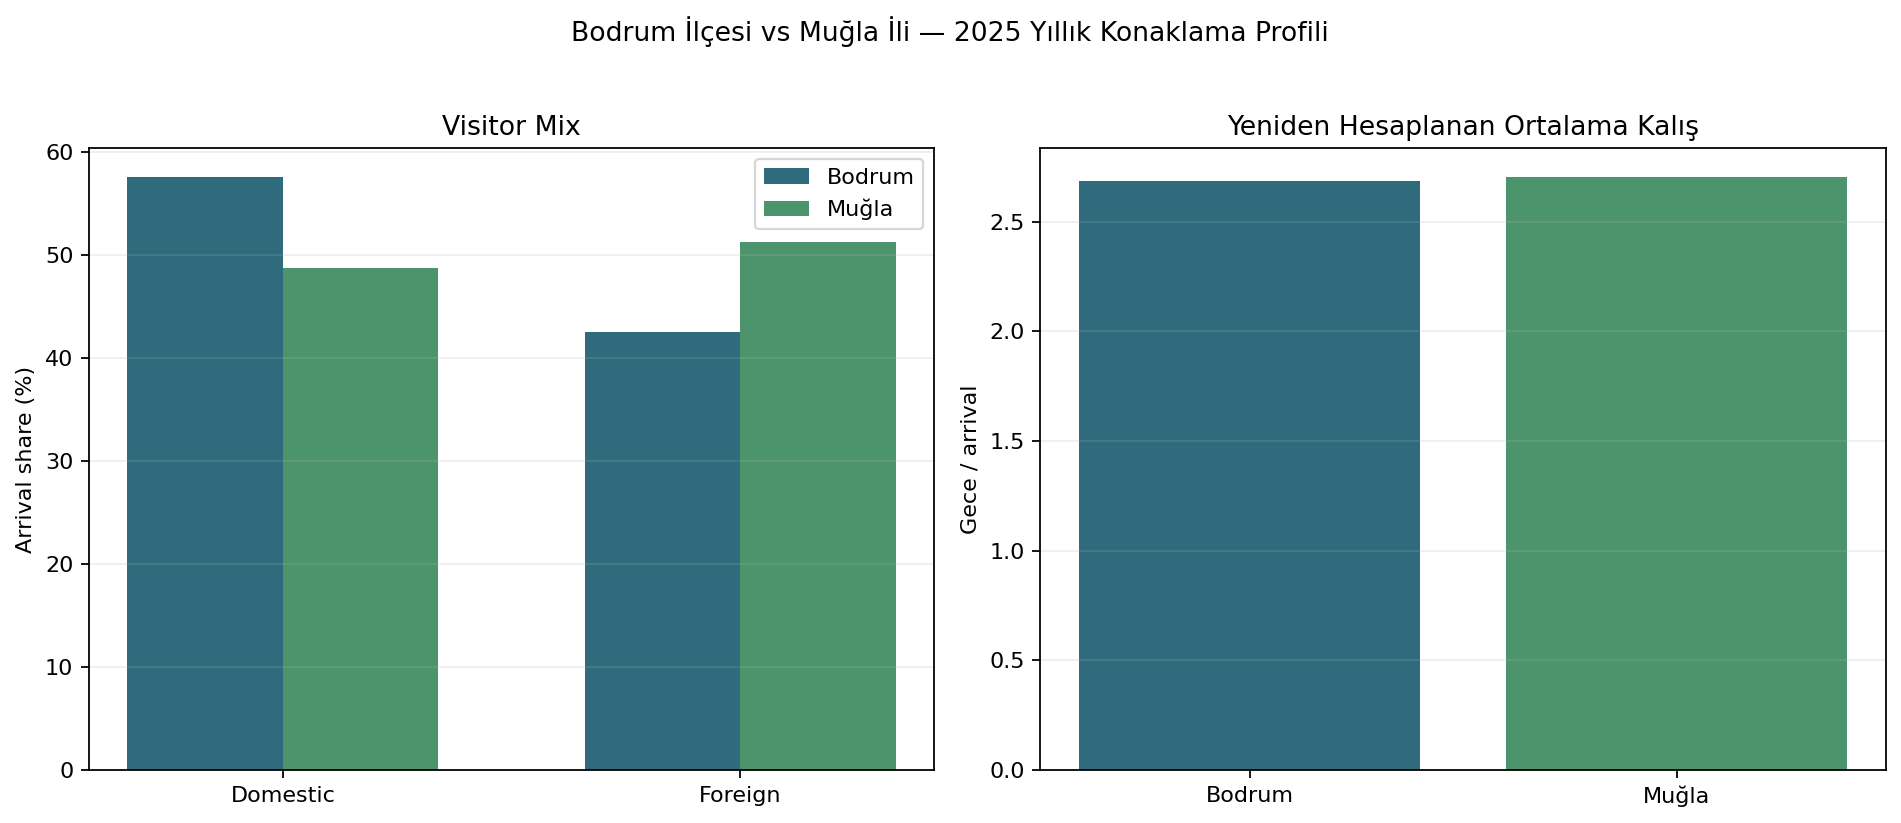

*Şekil 12 — Bodrum ve Muğla visitor mix karşılaştırması (Notebook 09).*

### Grafik nasıl okunur?
Yığılmış oranlar domestic ve foreign geliş paylarını karşılaştırır.

### Ne görüyoruz?
Bodrum domestic payı %57,5; Muğla foreign payı %51,3.

### Neden önemli?
İlçe ile ilin yıllık ziyaretçi kompozisyonunun aynı olmadığını gösterir.

### Dikkat edilmesi gereken nokta
Bu ortak yıllık konaklama-istatistiği tanımı içindeki karşılaştırmadır; tüm seyahat hareketlerini kapsamaz.

In [25]:
show_figure(
    "reports/figures/tourism_demand/14_bodrum_vs_mugla_visitor_mix_2025.png",
    "Şekil 12 — Bodrum ve Muğla visitor mix karşılaştırması (Notebook 09).",
    "Yığılmış oranlar domestic ve foreign geliş paylarını karşılaştırır.",
    f"Bodrum domestic payı {format_pct_tr(bodrum_vs_mugla['bodrum_domestic_share_pct'])}; Muğla foreign payı {format_pct_tr(bodrum_vs_mugla['mugla_foreign_share_pct'])}.",
    "İlçe ile ilin yıllık ziyaretçi kompozisyonunun aynı olmadığını gösterir.",
    "Bu ortak yıllık konaklama-istatistiği tanımı içindeki karşılaştırmadır; tüm seyahat hareketlerini kapsamaz."
)


### Bölüm Sonucu

Bodrum, Muğla 2025 geliş ve gecelemelerinin yaklaşık üçte birini oluşturuyor; visitor mix'i il
geneline göre daha domestic ağırlıklı. İşletmeci ve planlayıcı yıllık ölçeği kullanabilir, fakat
Bodrum'a aylık sezon profili atayamaz.


## 13. Milas-Bodrum Airport × Tourism

In [26]:
international_peak = airport_joint.loc[airport_joint["airport_international_passengers"].idxmax()]
display(Markdown(
    "#### 2025 ortak sezon özeti\n\n"
    f"- Airport total passengers: **{format_number_tr(airport_joint['airport_total_passengers'].sum())}**\n"
    f"- Peak total month: **{peak_airport['month_name_tr']} — {format_number_tr(peak_airport['airport_total_passengers'])}**\n"
    f"- International peak: **{international_peak['month_name_tr']} — {format_number_tr(international_peak['airport_international_passengers'])}**\n"
    f"- Muğla tourism peak: **{peak_tourism['month_name_tr']} — {format_number_tr(peak_tourism['total_arrivals'])}**\n"
    f"- Largest normalized divergence: **{largest_divergence['month']} — {format_number_tr(largest_divergence['abs_total_gap'], 1)} puan**\n\n"
    "Airport passengers ile accommodation arrivals farklı population ve grain'lerdir."
))


#### 2025 ortak sezon özeti

- Airport total passengers: **4.412.884**
- Peak total month: **Ağustos — 822.443**
- International peak: **Ağustos — 381.648**
- Muğla tourism peak: **Ağustos — 2.003.174**
- Largest normalized divergence: **Haziran — 56,8 puan**

Airport passengers ile accommodation arrivals farklı population ve grain'lerdir.

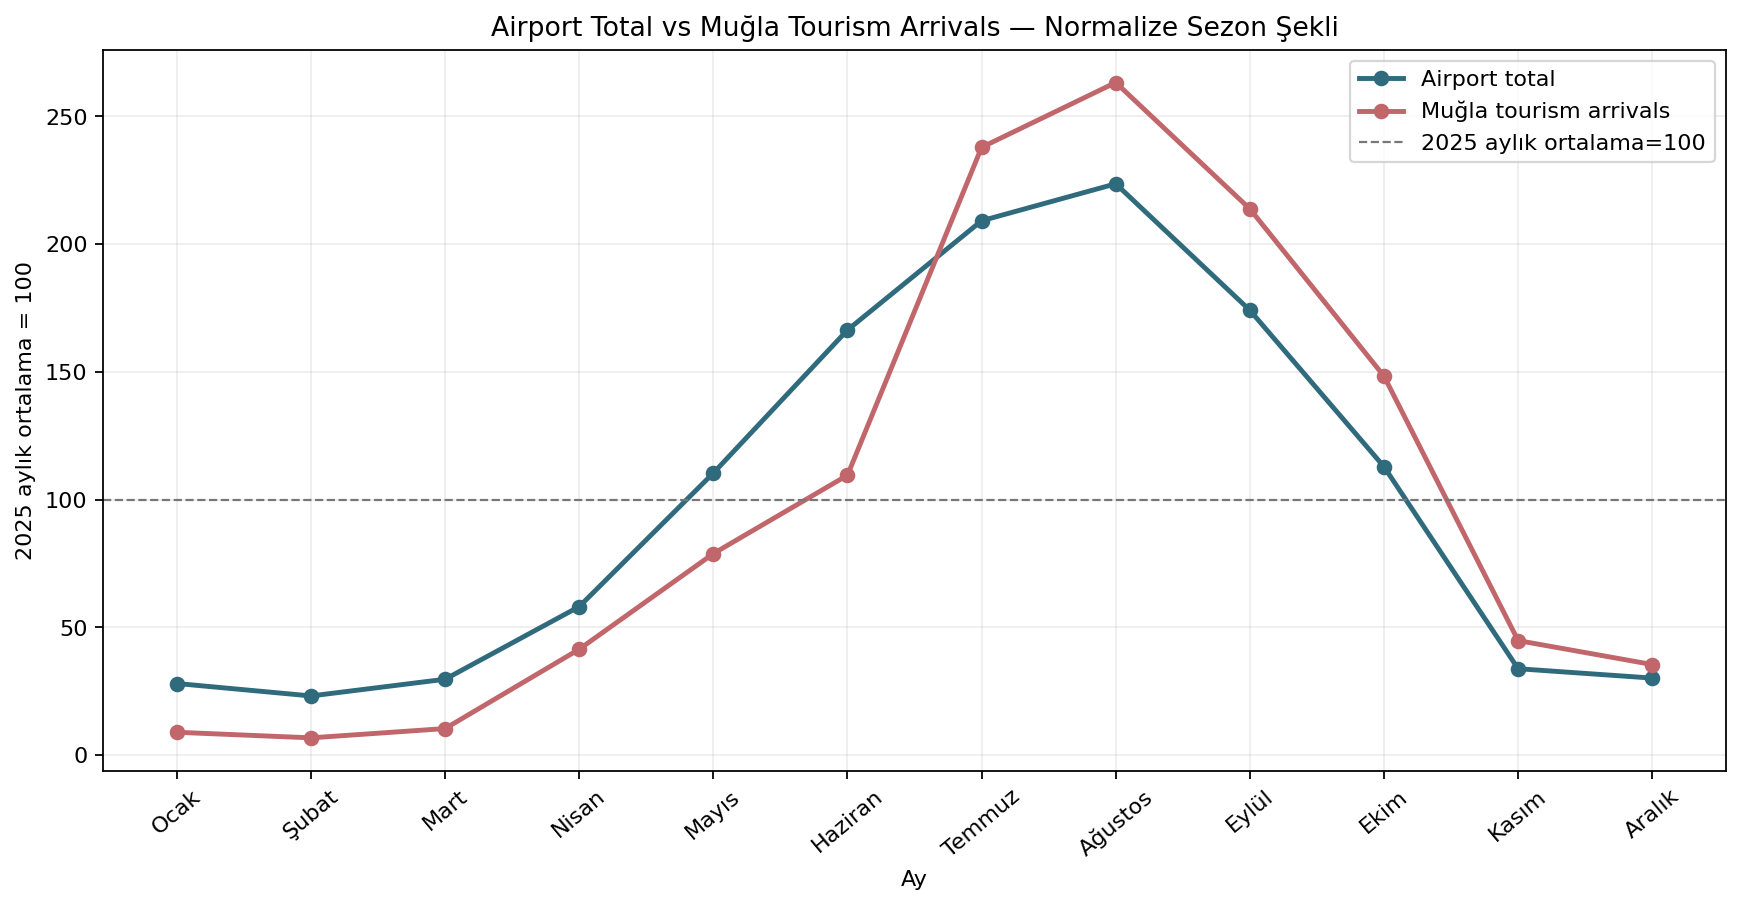

*Şekil 13 — Airport total passengers × Muğla tourism arrivals, normalize sezon (Notebook 10).*

### Grafik nasıl okunur?
Her seri kendi 2025 aylık ortalamasına göre 100'e normalize edilmiştir; biçim karşılaştırılır, ham adet değil.

### Ne görüyoruz?
İki seri aynı aylarda çok güçlü sıralı hareket ediyor (ρ=0,986, n=12) ve ikisi de Ağustos'ta zirve yapıyor.

### Neden önemli?
Farklı ölçeklerdeki ulaşım ve konaklama serilerinin sezon şekillerini karşılaştırmayı sağlar.

### Dikkat edilmesi gereken nokta
Yüksek korelasyon aynı aylarda benzer hareket demektir; nedensellik, kişi eşitliği veya Bodrum aylık turizmi değildir.

In [27]:
show_figure(
    "reports/figures/airport_tourism/03_airport_vs_tourism_normalized.png",
    "Şekil 13 — Airport total passengers × Muğla tourism arrivals, normalize sezon (Notebook 10).",
    "Her seri kendi 2025 aylık ortalamasına göre 100'e normalize edilmiştir; biçim karşılaştırılır, ham adet değil.",
    f"İki seri aynı aylarda çok güçlü sıralı hareket ediyor (ρ={format_number_tr(airport_total_rho, 3)}, n={airport_corr_n}) ve ikisi de Ağustos'ta zirve yapıyor.",
    "Farklı ölçeklerdeki ulaşım ve konaklama serilerinin sezon şekillerini karşılaştırmayı sağlar.",
    "Yüksek korelasyon aynı aylarda benzer hareket demektir; nedensellik, kişi eşitliği veya Bodrum aylık turizmi değildir."
)


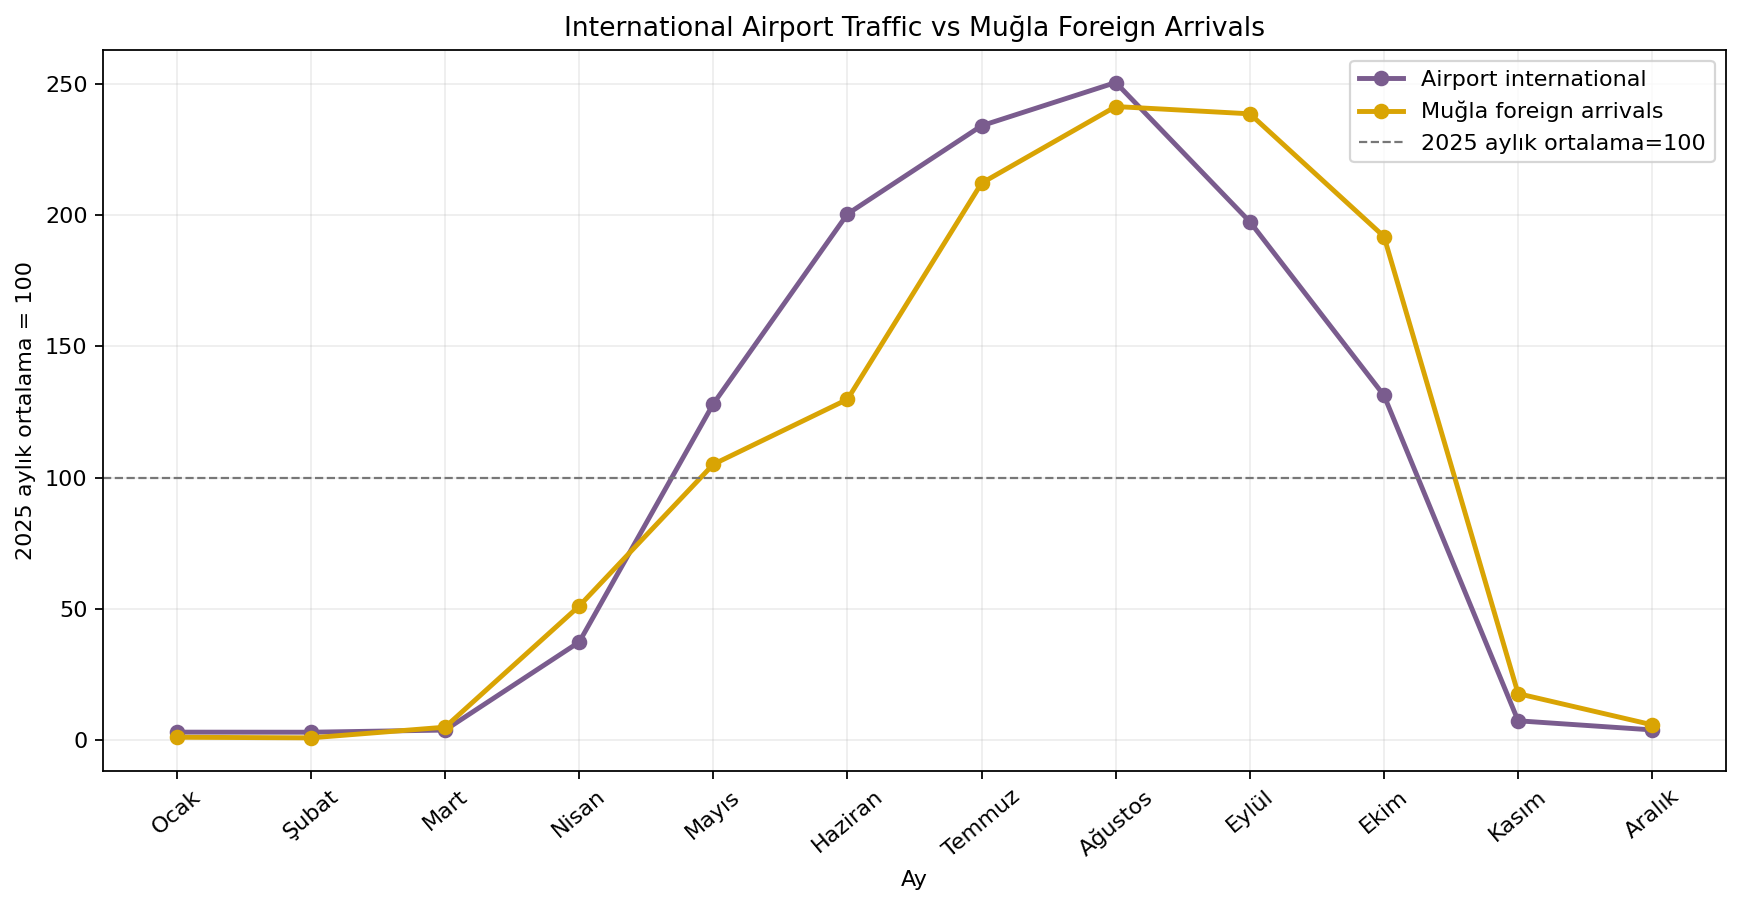

*Şekil 14 — Dış hat yolcu × yabancı geliş normalize sezonu (Notebook 10).*

### Grafik nasıl okunur?
Her seri kendi aylık ortalamasına göre indekslenmiştir; 100 ortalama ayı gösterir.

### Ne görüyoruz?
International passengers ile Muğla foreign arrivals ilişkisi ρ=0,965 (n=12); peak ay Ağustos.

### Neden önemli?
Uluslararası erişim ile yabancı konaklama talebinin sezon ritmini birlikte görmeyi sağlar.

### Dikkat edilmesi gereken nokta
Dış hat yolcu yabancı turist demek değildir; transfer, yerel ve diğer seyahat amaçları olabilir.

In [28]:
show_figure(
    "reports/figures/airport_tourism/04_international_vs_foreign_normalized.png",
    "Şekil 14 — Dış hat yolcu × yabancı geliş normalize sezonu (Notebook 10).",
    "Her seri kendi aylık ortalamasına göre indekslenmiştir; 100 ortalama ayı gösterir.",
    f"International passengers ile Muğla foreign arrivals ilişkisi ρ={format_number_tr(airport_foreign_rho, 3)} (n=12); peak ay Ağustos.",
    "Uluslararası erişim ile yabancı konaklama talebinin sezon ritmini birlikte görmeyi sağlar.",
    "Dış hat yolcu yabancı turist demek değildir; transfer, yerel ve diğer seyahat amaçları olabilir."
)


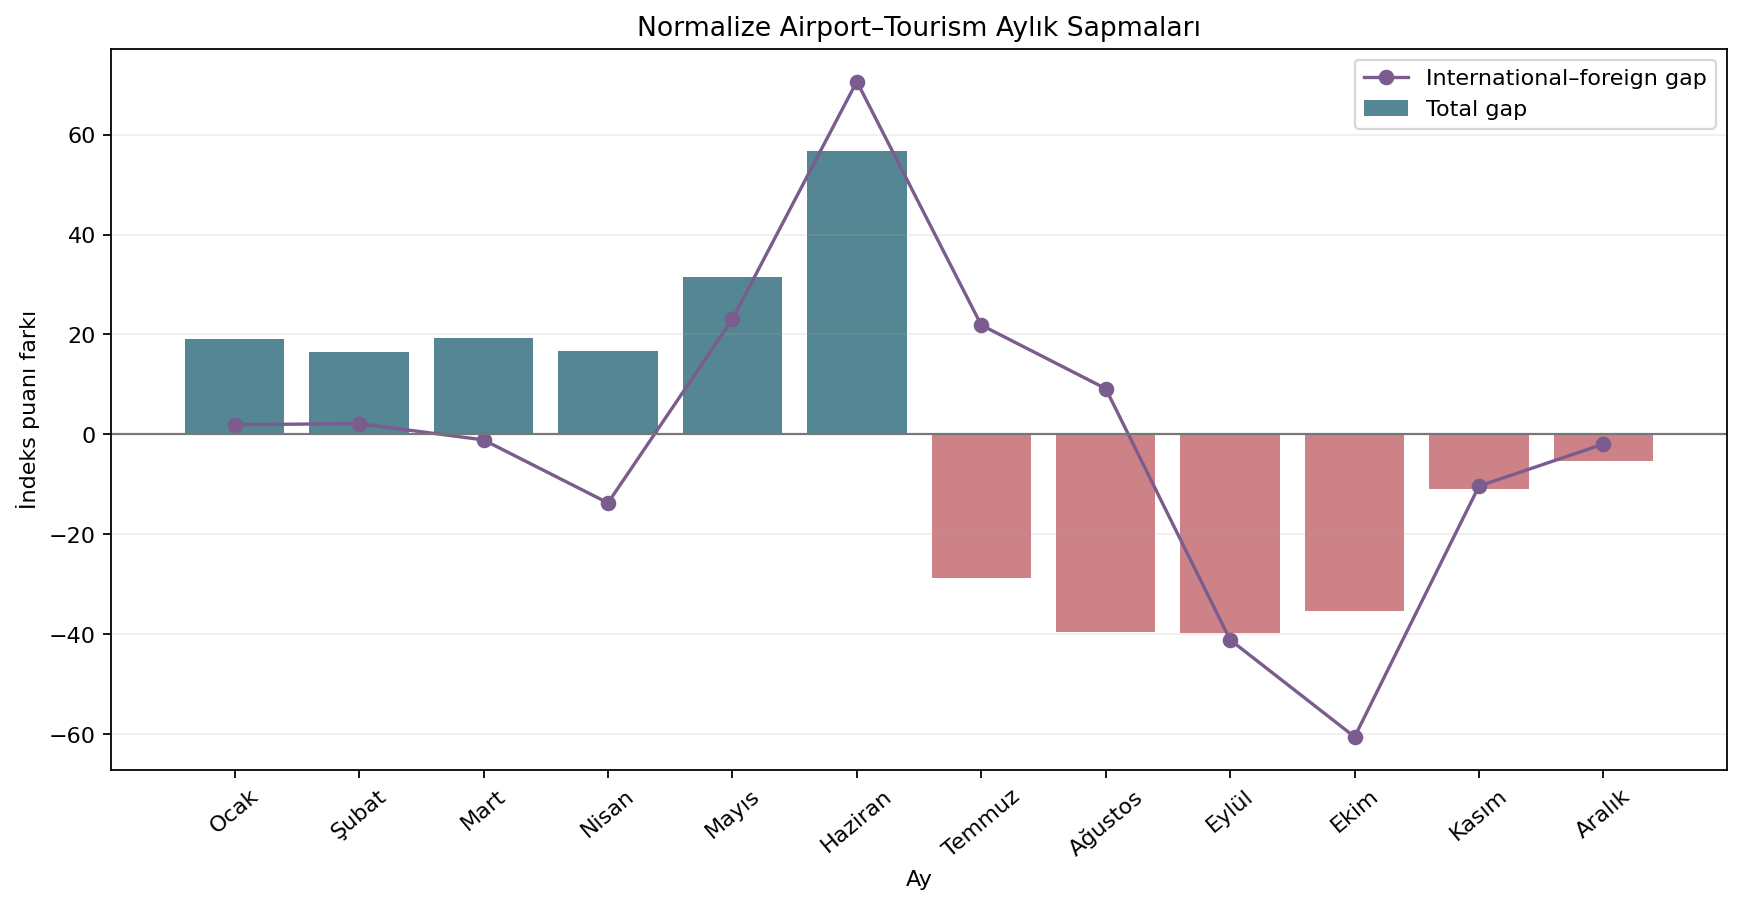

*Şekil 15 — Normalize airport–tourism divergence (Notebook 10).*

### Grafik nasıl okunur?
Sıfır çizgisi iki normalize serinin aynı göreli düzeyde olduğu ayı; mutlak büyüklük ayrışmayı gösterir.

### Ne görüyoruz?
En büyük total ayrışma Haziran ayında 56,8 indeks puanı.

### Neden önemli?
Güçlü yıllık korelasyonun her ay tam hizalanma anlamına gelmediğini gösterir.

### Dikkat edilmesi gereken nokta
Grafik ayrışmanın nedenini söylemez; takvim, ulaşım ağı veya konaklama davranışı açıklaması uydurulmamalıdır.

In [29]:
show_figure(
    "reports/figures/airport_tourism/11_monthly_divergence.png",
    "Şekil 15 — Normalize airport–tourism divergence (Notebook 10).",
    "Sıfır çizgisi iki normalize serinin aynı göreli düzeyde olduğu ayı; mutlak büyüklük ayrışmayı gösterir.",
    f"En büyük total ayrışma {largest_divergence['month']} ayında {format_number_tr(largest_divergence['abs_total_gap'], 1)} indeks puanı.",
    "Güçlü yıllık korelasyonun her ay tam hizalanma anlamına gelmediğini gösterir.",
    "Grafik ayrışmanın nedenini söylemez; takvim, ulaşım ağı veya konaklama davranışı açıklaması uydurulmamalıdır."
)


In [30]:
correlation_display = pd.DataFrame([
    ("Airport total × tourism arrivals", airport_total_rho),
    ("International airport × foreign arrivals", airport_foreign_rho),
    ("Domestic airport × domestic arrivals", airport_domestic_rho),
    ("Airport total × overnights", airport_overnight_rho),
    ("Airport total × occupancy", airport_occupancy_rho),
], columns=["Metric pair", "rho"])
correlation_display["Spearman"] = correlation_display["rho"].map(lambda x: "ρ=" + format_number_tr(x, 3))
correlation_display["Plain-language interpretation"] = correlation_display["rho"].map(interpret_spearman)
correlation_display = correlation_display[["Metric pair", "Spearman", "Plain-language interpretation"]]
table_title("Cross-domain korelasyonlar", "Spearman, iki serinin ay sıralamalarının birlikte değişimini ölçer; n=12 ve sonuçlar keşifseldir.")
display(correlation_display)


#### Cross-domain korelasyonlar

Spearman, iki serinin ay sıralamalarının birlikte değişimini ölçer; n=12 ve sonuçlar keşifseldir.

,Metric pair,Spearman,Plain-language interpretation
0,Airport total × tourism arrivals,"ρ=0,986","Çok güçlü, aynı yönlü sıralı birliktelik; nedensellik göstermez."
1,International airport × foreign arrivals,"ρ=0,965","Çok güçlü, aynı yönlü sıralı birliktelik; nedensellik göstermez."
2,Domestic airport × domestic arrivals,"ρ=0,930","Çok güçlü, aynı yönlü sıralı birliktelik; nedensellik göstermez."
3,Airport total × overnights,"ρ=0,993","Çok güçlü, aynı yönlü sıralı birliktelik; nedensellik göstermez."
4,Airport total × occupancy,"ρ=0,993","Çok güçlü, aynı yönlü sıralı birliktelik; nedensellik göstermez."


In [31]:
lag_display = airport_lags[["metric_pair", "lag_months", "alignment", "n", "spearman_rho"]].copy()
lag_display["spearman_rho"] = lag_display["spearman_rho"].round(3)
table_title("Lag 0 ve lag 1", "Lag 0 aynı ayı, lag 1 airport_t ile tourism_t+1 karşılaştırmasını ifade eder.")
display(lag_display)


#### Lag 0 ve lag 1

Lag 0 aynı ayı, lag 1 airport_t ile tourism_t+1 karşılaştırmasını ifade eder.

,metric_pair,lag_months,alignment,n,spearman_rho
0,total airport vs total tourism,0,airport_t vs tourism_t,12,0.986
1,total airport vs total tourism,1,airport_t vs tourism_t+1,11,0.909
2,international airport vs foreign tourism,0,airport_t vs tourism_t,12,0.965
3,international airport vs foreign tourism,1,airport_t vs tourism_t+1,11,0.909
4,domestic airport vs domestic tourism,0,airport_t vs tourism_t,12,0.930
5,domestic airport vs domestic tourism,1,airport_t vs tourism_t+1,11,0.927


> **Zorunlu yorum uyarısı:** Yüksek korelasyon = aynı aylarda benzer hareket. Nedensellik değildir.
> Airport passengers, Bodrum tourist arrivals değildir. Muğla tourism arrivals, Bodrum monthly
> arrivals değildir.

### Bölüm Sonucu

Airport ve Muğla tourism serileri 2025'te güçlü biçimde eşzamanlı hareket etti; lag 0 ilişkileri
genellikle lag 1'den daha güçlü. Bu, ulaşım ve konaklama sezon ritminin birlikte izlenebileceğini
gösterir; conversion rate, turist sayısı veya causal etki üretmez.


## 14. Bütünsel Bulgular

In [32]:
key_findings = pd.DataFrame([
    ("F01", "Data", f"Hotel snapshot {hotel_count} benzersiz otel ve {destination_count} destinasyon içeriyor.", "hotel_count / destination_count", f"{hotel_count} / {destination_count}", "HIGH", "Örneklem tam census olmayabilir.", "01–03"),
    ("F02", "Data quality", "Tam satır duplicate yok; tüm cleaning kontrolleri geçti.", "duplicate_rows / validation", f"0 / {len(cleaning)} PASS", "HIGH", "Geçen kontroller analitik zenginlik garantisi değildir.", "02–03"),
    ("F03", "Hotel market", "Fiyat snapshot coverage yüksek fakat tek tarihlidir.", "price coverage", f"{price_n}/{hotel_count} ({price_coverage_pct:.1f}%)", "MEDIUM", "Yıllık fiyat stratejisi değildir.", "02/05"),
    ("F04", "Official match", "Resmî özellikler yalnız yüksek güvenli eşleşmelerde kullanıldı.", "high-confidence match", f"{high_confidence_n}/{hotel_count} ({official_coverage_pct:.1f}%)", "HIGH", "Coverage eksik; eşleşmeyen otellere özellik atanmadı.", "06"),
    ("F05", "Official attributes", "Resmî yıldız ile Google rating ilişkisi zayıf.", "Spearman", f"rho={star_rating_row['statistic']:.3f}, n={int(star_rating_row['n'])}", "MEDIUM", "Küçük gruplar; nedensellik yok.", "07"),
    ("F06", "Official attributes", "5 yıldız medyan fiyat snapshot'ı 4 yıldızdan daha yüksek.", "median price", f"${star5['median_price_snapshot']:.0f} vs ${star4['median_price_snapshot']:.0f} (+{star_price_diff_pct:.1f}%)", "MEDIUM", "Tek fiyat snapshot'ı; n=19/15.", "07"),
    ("F07", "Capacity", "Oda sayısı ile Google yorum hacmi güçlü birlikte değişiyor.", "Spearman", f"rho={room_review_row['statistic']:.3f}, n={int(room_review_row['n'])}", "MEDIUM", "Review count gerçek misafir sayısı değildir.", "07"),
    ("F08", "Destination", f"Ağırlıklı memnuniyet sinyali en yüksek alan {top_weighted['area']}.", "weighted rating", f"{top_weighted['avg_weighted_google_rating']:.3f}", "MEDIUM", "Platform puanı; örneklem içi karşılaştırma.", "08"),
    ("F09", "Destination", f"Toplam Google görünürlüğü en yüksek alan {top_reviews['area']}.", "total reviews", f"{int(top_reviews['total_google_reviews'])}", "MEDIUM", "Görünürlük talep veya kaliteye eşit değildir.", "08"),
    ("F10", "Destination", f"Fiyat snapshot indeksi en yüksek alan {top_price_index['area']}.", "price index", f"{top_price_index['price_index']:.1f}", "MEDIUM", "Tek tarihli fiyat snapshot'ı.", "08"),
    ("F11", "Destination", "14 alanın 10'u düşük resmî coverage taşıyor.", "low coverage areas", "10/14", "HIGH", "Luxury/capacity rank'leri kısıtlıdır.", "08"),
    ("F12", "Tourism", "Muğla toplam geliş 2009–2025 arasında güçlü arttı.", "total arrival change", f"{(annual_2025['total_arrivals']/tourism_annual.iloc[0]['total_arrivals']-1)*100:.1f}%", "HIGH", "İl düzeyi resmî konaklama serisi.", "09"),
    ("F13", "Tourism", "2020, 2019'a göre keskin kırılma gösterdi.", "total arrivals YoY", f"{annual_2020['total_arrivals_yoy_pct']:.1f}%", "HIGH", "Betimsel yıllık değişim.", "09"),
    ("F14", "Tourism", "2025 seride en yüksek toplam geliş yılıdır.", "total arrivals", f"{int(annual_2025['total_arrivals'])}", "HIGH", "Muğla ili; tüm seyahatleri kapsamaz.", "09"),
    ("F15", "Seasonality", "İlk üç ay 2025 gelişlerinin çoğunu topladı.", "top-3 month share", f"{seasonality['top3_month_arrival_share_pct']:.1f}%", "HIGH", "Muğla aylık serisi Bodrum değildir.", "09"),
    ("F16", "Bodrum", "Bodrum, Muğla 2025 gelişlerinin yaklaşık üçte birini oluşturdu.", "Bodrum share", f"{bodrum_vs_mugla['bodrum_share_of_mugla_total_arrivals_pct']:.1f}%", "HIGH", "Yıllık ortak konaklama-istatistiği kapsamı.", "09"),
    ("F17", "Bodrum", "Bodrum visitor mix'i domestic ağırlıklıdır.", "domestic share", f"{bodrum_vs_mugla['bodrum_domestic_share_pct']:.1f}%", "HIGH", "Yalnız 2025 yıllık profil.", "09"),
    ("F18", "Airport", "Milas-Bodrum Airport 2025 toplam yolcu sayısı doğrulandı.", "annual passengers", f"{int(airport_joint['airport_total_passengers'].sum())}", "HIGH", "Passenger turist değildir; seri kesin olmayan DHMİ notu taşır.", "10"),
    ("F19", "Airport × Tourism", "Airport total ve Muğla arrivals aynı aylarda çok güçlü hareket etti.", "Spearman", f"rho={airport_total_rho:.3f}, n={airport_corr_n}", "MEDIUM", "Farklı population/grain; nedensellik yok.", "10"),
    ("F20", "Airport × Tourism", f"En büyük normalize ayrışma {largest_divergence['month']} ayında oluştu.", "absolute index gap", f"{largest_divergence['abs_total_gap']:.1f}", "MEDIUM", "Nedeni veri tarafından açıklanmıyor.", "10"),
], columns=["finding_id", "layer", "finding", "evidence_metric", "evidence_value", "confidence", "main_limitation", "source_notebook"])

key_findings.to_csv(REPORTS_DIR / "project_key_findings_master.csv", index=False)

top10_ids = ["F01", "F03", "F04", "F05", "F08", "F12", "F15", "F16", "F18", "F19"]
top10 = key_findings.set_index("finding_id").loc[top10_ids].reset_index()
top10_display = top10[["finding", "evidence_value", "confidence", "main_limitation"]].rename(columns={
    "finding": "Bulgu", "evidence_value": "Kanıt", "confidence": "Güven seviyesi", "main_limitation": "Sınırlılık"
})
table_title("En Güçlü 10 Bulgu", "HIGH doğrudan tanımlı sayım/tutarlılığı; MEDIUM coverage, proxy veya küçük örneklem sınırı olan geçerli sinyali gösterir.")
display(top10_display)


#### En Güçlü 10 Bulgu

HIGH doğrudan tanımlı sayım/tutarlılığı; MEDIUM coverage, proxy veya küçük örneklem sınırı olan geçerli sinyali gösterir.

,Bulgu,Kanıt,Güven seviyesi,Sınırlılık
0,Hotel snapshot 192 benzersiz otel ve 14 destinasyon içeriyor.,192 / 14,HIGH,Örneklem tam census olmayabilir.
1,Fiyat snapshot coverage yüksek fakat tek tarihlidir.,168/192 (87.5%),MEDIUM,Yıllık fiyat stratejisi değildir.
2,Resmî özellikler yalnız yüksek güvenli eşleşmelerde kullanıldı.,52/192 (27.1%),HIGH,Coverage eksik; eşleşmeyen otellere özellik atanmadı.
3,Resmî yıldız ile Google rating ilişkisi zayıf.,"rho=0.238, n=51",MEDIUM,Küçük gruplar; nedensellik yok.
4,Ağırlıklı memnuniyet sinyali en yüksek alan Gündoğan.,4.417,MEDIUM,Platform puanı; örneklem içi karşılaştırma.
5,Muğla toplam geliş 2009–2025 arasında güçlü arttı.,176.5%,HIGH,İl düzeyi resmî konaklama serisi.
6,İlk üç ay 2025 gelişlerinin çoğunu topladı.,59.6%,HIGH,Muğla aylık serisi Bodrum değildir.
7,"Bodrum, Muğla 2025 gelişlerinin yaklaşık üçte birini oluşturdu.",30.9%,HIGH,Yıllık ortak konaklama-istatistiği kapsamı.
8,Milas-Bodrum Airport 2025 toplam yolcu sayısı doğrulandı.,4412884,HIGH,Passenger turist değildir; seri kesin olmayan DHMİ notu taşır.
9,Airport total ve Muğla arrivals aynı aylarda çok güçlü hareket etti.,"rho=0.986, n=12",MEDIUM,Farklı population/grain; nedensellik yok.


### Bu Projeden Ne Öğrendik?

- Otel sayısı, yorum görünürlüğü, müşteri puanı, fiyat ve resmî kapasite farklı pazar boyutlarıdır.
- Review sayısı dijital görünürlük sinyalidir; gerçek misafir sayısı değildir.
- Resmî yıldız sınıfı ile müşteri puanı aynı kavram değildir ve aralarındaki ilişki zayıftır.
- Destinasyonlar quality, popularity, price, luxury, value ve capacity boyutlarında farklı profiller verir.
- Coverage, özellikle luxury ve capacity yorumunun ayrılmaz parçasıdır.
- Muğla talebi uzun dönemde büyümüş, 2020'de kırılmış ve 2025'te serinin en yüksek ölçeğine çıkmıştır.
- 2025 aylık talebi belirgin biçimde yaz aylarında yoğunlaşmıştır.
- Bodrum'un yıllık visitor mix'i Muğla il genelinden daha domestic ağırlıklıdır.
- Airport ve konaklama serileri aynı sezon ritmini güçlü biçimde paylaşır.
- Güçlü korelasyon her ay tam hizalanma veya neden-sonuç demek değildir.

### Bölüm Sonucu

Katmanlar ortak bir pazar hikâyesi kuruyor: heterojen destinasyon arzı, eksik ama değerli resmî
kapasite bağlamı ve güçlü sezonluk talep/ulaşım hareketi. Bu hikâye farklı grain'leri zorla join
etmeden, kanıtların sınırlarını korur.


## 15. Bu Verilerle Ne Söyleyemeyiz?

- Tek fiyat snapshot'ından yıllık fiyat stratejisi, gelir veya fiyat esnekliği çıkaramayız.
- Google review sayısından gerçek misafir, rezervasyon veya pazar payı çıkaramayız.
- Google rating'i resmî yıldız sınıfı gibi okuyamayız.
- Official star coverage eksik alanlarda kesin luxury rank veremeyiz.
- Eşleşmeyen alandaki boş kapasiteyi sıfır kapasite sayamayız.
- Muğla monthly demand'ı Bodrum aylık demand'ı gibi okuyamayız.
- Airport passengers'ı tourist arrivals ile eşitleyemeyiz.
- Korelasyondan nedensellik, tahmin gücü veya conversion rate çıkaramayız.
- Farklı tarih/grain katmanlarını aynı anın tek ölçümü gibi sunamayız.


## 16. Genel Sınırlılıklar

1. Hotel dataset tam census olmayabilir; platformda gözlenebilen örneklemdir.
2. Google rating/review metrikleri platform kullanıcı davranışı ve görünürlük etkisi taşır.
3. `search_price_usd_snapshot` tek tarihlidir; oda/kişi/koşul standardı bilinmez.
4. Resmî matching coverage 52/192'dir ve 10/14 alanda düşüktür.
5. Bazı alanlarda resmî örneklem çok küçüktür; sıralama hassastır.
6. Destinasyon evreni 14 alanla sınırlıdır; indeksler örneklem içi göreli ölçüdür.
7. Aylık tourism serisi Muğla il düzeyidir; Bodrum aylık serisi yoktur.
8. Bodrum tourism profili yalnız 2025 yıllık ilçe düzeyindedir.
9. Airport passenger ile accommodation arrival aynı kişi/population değildir.
10. Hotel snapshot (2026), tourism/airport (2025) ve uzun dönem tourism serileri farklı zaman kapsamındadır.
11. n=12 aylık korelasyonlar keşifseldir ve causal değildir.


## 17. Sonuç

### Otel Pazarı

Bodrum hotel snapshot'ı 192 tesiste yüksek dijital görünürlük çeşitliliği, dar ama anlamlı rating
farkları ve destinasyonlara göre güçlü göreli fiyat ayrışması gösteriyor. Bu üç sinyal birbirinin
yerine geçmiyor.

### Destinasyon Yapısı

14 destinasyon arz, quality, popularity, price, luxury, value ve capacity boyutlarında farklılaşıyor.
Tek score yerine alt indeksler daha açıklanabilir; resmî coverage düşük olduğunda luxury/capacity
yorumları özellikle ihtiyat gerektiriyor.

### Turizm Talebi ve Sezonluk Hareket

Muğla resmî serisi uzun dönem büyümeyi, 2020 kırılmasını ve 2025'te yüksek ölçekli fakat güçlü
sezon yoğunlaşmalı talebi gösteriyor. Bodrum 2025 yıllık profili Muğla toplamının yaklaşık üçte
birini ve daha domestic ağırlıklı bir mix'i temsil ediyor.

### Genel Sonuç

Milas-Bodrum Airport ve Muğla accommodation demand aynı sezon ritminde çok güçlü hareket ediyor;
ancak ulaşım yolcusu ile turist gelişi eşitlenemez. Projenin en güvenilir sonucu tek bir “en iyi”
sıralaması değil, kapsamı açık ve birbirini tamamlayan intelligence katmanlarıdır.


In [33]:
consistency_checks = pd.DataFrame([
    consistency_row("hotel_count", audit_map["rows"], len(hotels)),
    consistency_row("destination_count", audit_map["destination_count"], hotels["area"].nunique()),
    consistency_row("official_high_confidence_match_count", match_map["high_confidence_matches"], hotels_enriched["official_match_status"].eq("MATCHED_HIGH_CONFIDENCE").sum()),
    consistency_row("official_facility_count", match_map["official_facilities_total"], len(official)),
    consistency_row("airport_annual_total", airport_seasonality["airport_annual_total_passengers"], airport_joint["airport_total_passengers"].sum()),
    consistency_row("mugla_2025_total_arrivals", annual_2025["total_arrivals"], tourism_monthly["total_arrivals"].sum()),
    consistency_row("mugla_2025_total_overnights", annual_2025["total_overnights"], tourism_monthly["total_overnights"].sum()),
    consistency_row("bodrum_2025_total_arrivals", bodrum_2025["total_arrivals"], bodrum_2025["domestic_arrivals"] + bodrum_2025["foreign_arrivals"]),
])
consistency_checks.to_csv(REPORTS_DIR / "project_summary_consistency_checks.csv", index=False)
table_title("Kritik KPI consistency checks", "Notebook/rapor değeri bağımsız processed kaynak toplamı veya sayımıyla karşılaştırıldı.")
display(consistency_checks)
assert consistency_checks["status"].eq("PASS").all(), "Kritik KPI tutarsızlığı var; final özet yayımlanmamalıdır."


#### Kritik KPI consistency checks

Notebook/rapor değeri bağımsız processed kaynak toplamı veya sayımıyla karşılaştırıldı.

,metric,notebook_report_value,recomputed_value,difference,status
0,hotel_count,192.0,192.0,0.0,PASS
1,destination_count,14.0,14.0,0.0,PASS
2,official_high_confidence_match_count,52.0,52.0,0.0,PASS
3,official_facility_count,168.0,168.0,0.0,PASS
4,airport_annual_total,4412884.0,4412884.0,0.0,PASS
5,mugla_2025_total_arrivals,9129867.0,9129867.0,0.0,PASS
6,mugla_2025_total_overnights,24669490.0,24669490.0,0.0,PASS
7,bodrum_2025_total_arrivals,2823425.0,2823425.0,0.0,PASS


## 18. Bundan Sonra Ne Yapacağız?

1. Şikayetvar all-hotel discovery + scraping
2. Complaint audit / cleaning
3. Complaint EDA
4. NLP / aspect analysis
5. Hotel segmentation
6. Anomaly / opportunity analysis
7. Recommendation system
8. Final dashboard

Şikayetvar branch'i henüz bu notebookun bulgularına dahil edilmedi. Customer voice verisi önce
otel kapsamı, eşleştirme, duplicate, tarih ve içerik kalitesi açısından ayrı audit'ten geçmelidir.


In [34]:
selected_figures = pd.DataFrame([
    (1, "Hotel market", "reports/figures/eda/hotels_by_review_count.png", "Hotel visibility / review volume", "Hangi oteller dijital olarak en görünür?", "Görünürlüğü kaliteyle eşitlemeden gösterir.", "05"),
    (2, "Hotel market", "reports/figures/eda/rating_vs_review_count.png", "Rating × review count", "Puan ve görünürlük nasıl birlikte değişiyor?", "İki ayrı pazar boyutunu ve outlier'ları gösterir.", "05"),
    (3, "Hotel market", "reports/figures/eda/median_price_by_destination.png", "Median price by destination", "Alanlar tek snapshot'ta nasıl fiyatlanıyor?", "Güçlü ve okunabilir destinasyon fiyat farkı.", "05"),
    (4, "Official matching", "reports/figures/destination_intelligence/coverage_by_area.png", "Official match coverage", "Resmî sonuçlar nerede güvenilir?", "Coverage'ı yorumun merkezine koyar.", "06/08"),
    (5, "Official attributes", "reports/figures/hotel_attributes/rating_by_star.png", "Rating by verified star", "Yıldız ve müşteri algısı birlikte nasıl değişiyor?", "Resmî sınıf ile platform puanını ayırır.", "07"),
    (6, "Official attributes", "reports/figures/hotel_attributes/median_price_by_star.png", "Median price by verified star", "Yıldız grupları snapshot fiyatta ayrışıyor mu?", "Medyan ve n ile sade karşılaştırma.", "07"),
    (7, "Official attributes", "reports/figures/hotel_attributes/destination_room_capacity.png", "Official room capacity by destination", "Otel sayısı kapasiteyle aynı mı?", "Sayım ile kapasite farkını gösterir.", "07"),
    (8, "Destination", "reports/figures/destination_intelligence/destination_subindices_heatmap.png", "Destination sub-indices", "14 alan hangi boyutlarda farklılaşıyor?", "Tek score yerine çok boyutlu profil.", "08"),
    (9, "Destination", "reports/figures/destination_intelligence/popularity_satisfaction_quadrant.png", "Popularity × satisfaction", "Görünürlük ve memnuniyet nasıl ayrışıyor?", "Tekrar etmeyen iki boyutlu destination özeti.", "08"),
    (10, "Tourism", "reports/figures/tourism_demand/01_total_arrivals_2009_2025.png", "Muğla annual arrivals", "Uzun dönem talep nasıl değişti?", "2019, 2020 ve toparlanma kırılmalarını taşır.", "09"),
    (11, "Seasonality", "reports/figures/tourism_demand/06_monthly_total_arrivals_2025.png", "Muğla monthly arrivals", "2025 talebi ne kadar sezonluk?", "Peak ve yoğunlaşmayı doğrudan gösterir.", "09"),
    (12, "Bodrum", "reports/figures/tourism_demand/14_bodrum_vs_mugla_visitor_mix_2025.png", "Bodrum vs Muğla visitor mix", "İlçe ve il ziyaretçi kompozisyonu farklı mı?", "Aynı yıllık tanım içinde karşılaştırılabilir.", "09"),
    (13, "Airport × Tourism", "reports/figures/airport_tourism/03_airport_vs_tourism_normalized.png", "Normalized airport × tourism", "İki sezon şekli birlikte mi hareket ediyor?", "Farklı ölçekleri doğru biçimde karşılaştırır.", "10"),
    (14, "Airport × Tourism", "reports/figures/airport_tourism/04_international_vs_foreign_normalized.png", "International × foreign", "Uluslararası erişim ve yabancı talep nasıl hizalanıyor?", "Alt segmentte de ortak sezonu test eder.", "10"),
    (15, "Airport × Tourism", "reports/figures/airport_tourism/11_monthly_divergence.png", "Monthly normalized divergence", "Güçlü korelasyon hangi aylarda ayrışıyor?", "Korelasyonun sakladığı aylık farkı gösterir.", "10"),
], columns=["figure_order", "section", "figure_path", "figure_title", "research_question", "why_selected", "source_notebook"])
selected_figures.to_csv(REPORTS_DIR / "project_selected_figures.csv", index=False)
missing_figures = [path for path in selected_figures["figure_path"] if not (PROJECT_ROOT / path).exists()]
assert not missing_figures, f"Eksik seçili figürler: {missing_figures}"

top10_lines = "\n".join(
    f"{idx}. {row.finding} Kanıt: {row.evidence_value}. Güven: {row.confidence}."
    for idx, row in enumerate(top10.itertuples(), 1)
)
summary_text = f'''Bodrum Hotel & Destination Intelligence — Project Intelligence Summary

PROJECT PURPOSE
Bodrum konaklama pazarını hotel snapshot, güvenilir resmî tesis özellikleri, destination intelligence,
resmî turizm talebi ve airport seasonal co-movement katmanlarında açıklamak.

DATA SCOPE
- Hotels: {hotel_count} tesis, {destination_count} destinasyon, snapshot 2026-08-24.
- Official attributes: {high_confidence_n} yüksek güvenli eşleşme / {hotel_count} proje oteli.
- Tourism: Muğla annual 2009–2025, Muğla monthly 2025, Bodrum annual 2025.
- Airport: Milas-Bodrum monthly passengers, 2025.

TOP 10 FINDINGS
{top10_lines}

TOP LIMITATIONS
- Hotel örneklemi tam census olmayabilir; Google platform etkisi vardır.
- Fiyat yalnız tek snapshot'tır.
- Resmî eşleşme coverage eksiktir; 10/14 area düşük coverage taşır.
- Muğla monthly tourism Bodrum monthly tourism değildir.
- Airport passengers tourist arrivals değildir; correlation causation değildir.
- Katmanlar farklı zaman ve grain'lerde ölçülmüştür.

NEXT ANALYTICAL LAYERS
Şikayetvar discovery/scraping → complaint audit/cleaning → complaint EDA → NLP/aspect analysis →
hotel segmentation → anomaly/opportunity analysis → recommendation system → final dashboard.
'''
(REPORTS_DIR / "project_intelligence_summary.txt").write_text(summary_text, encoding="utf-8")

output_manifest = pd.DataFrame([
    ("Notebook", "notebooks/11_project_intelligence_summary.ipynb"),
    ("Key findings", "reports/project_key_findings_master.csv"),
    ("Selected figures", "reports/project_selected_figures.csv"),
    ("Consistency checks", "reports/project_summary_consistency_checks.csv"),
    ("Text summary", "reports/project_intelligence_summary.txt"),
], columns=["Çıktı", "Relative path"])
table_title("Final output manifest", f"{len(selected_figures)} ana figür seçildi; tüm relative path'ler doğrulandı.")
display(output_manifest)
print("Project intelligence summary outputs written and verified.")


#### Final output manifest

15 ana figür seçildi; tüm relative path'ler doğrulandı.

,Çıktı,Relative path
0,Notebook,notebooks/11_project_intelligence_summary.ipynb
1,Key findings,reports/project_key_findings_master.csv
2,Selected figures,reports/project_selected_figures.csv
3,Consistency checks,reports/project_summary_consistency_checks.csv
4,Text summary,reports/project_intelligence_summary.txt


Project intelligence summary outputs written and verified.


### Final okur testi

Bu notebook tek başına okunduğunda veri zincirini, beş ana soruyu, temel KPI'ları, seçilmiş 15
grafiğin ne anlattığını ve ne anlatmadığını verir. Her bulgu kaynak notebooka bağlanmış, kritik
KPI'lar processed veriden yeniden hesaplanmış ve Şikayetvar/customer voice henüz bulgu katmanına
eklenmemiştir.
